In [1]:
import os, sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, accuracy_score, average_precision_score, f1_score

import joblib

In [2]:
# Define the Neural Network Model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size=1):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)  # Batch normalization
        self.dropout1 = nn.Dropout(0.3)  # Dropout to avoid overfitting

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(hidden_size3, output_size)

    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(torch.relu(self.bn3(self.fc3(x))))
        x = self.fc4(x).squeeze(-1)
        return x


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            logits = model(inputs).squeeze(-1)
            probs = torch.sigmoid(logits)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    aupr = average_precision_score(all_labels, all_probs)
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auroc = float('nan')  # If only one class present

    return aupr, auroc


def create_directory(dir_path):
    """
    Creates a directory if it does not exist.

    Parameters:
    dir_path (str): Path to the directory to be created.
    """
    os.makedirs(dir_path, exist_ok=True)  # Creates the directory and ignores if it exists
    print(f"Directory '{dir_path}' is ready.")


In [4]:
def concat_df_in_dir(input_direc, iter_num=20, tail='.tsv', sep_='\t'):
    # Build file name tail list to ensure the correct order
    file_tail_list = []
    for i in range(iter_num):
        file_tail = '_' + str(i) + tail
        file_tail_list.append(file_tail)

    df_list = []
    files = os.listdir(input_direc)
    for f in range(iter_num):
        file_tail = file_tail_list[f]
        for file in files:
            if file.endswith(file_tail):
                print(file)
                df = pd.read_csv(input_direc+file, sep=sep_, index_col=None)
                df_list.append(df)
    df_all = pd.concat(df_list)
    return df_all


def create_GIV_input_df(input_dir="/home/myersc/zhan6668/DepGI/data/input/",
                    giv_dir='GIV/', iter_num=10):
    df_SL = concat_df_in_dir(input_dir+giv_dir, iter_num=iter_num, tail='.tsv')
    print(df_SL.shape)
    df_SL = df_SL.reset_index().drop('index', axis=1)
    return df_SL


def recall_at_k(y_true, y_pred, K):
    '''
    Compute Recall@K.
    Parameters:
    - y_true: array-like of shape (n_samples,), binary labels (1 for relevant, 0 for irrelevant)
    - y_pred: array-like of shape (n_samples,), predicted probabilities
    - K: int, number of top elements to consider
    Returns:
    - recall_at_K: float
    '''
    # Sort by predicted probability in descending order
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    # Count the number of relevant items in the top K
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    # Total number of relevant items in the entire dataset
    total_relevant = np.sum(y_true)
    # Recall@K formula
    return relevant_at_k / total_relevant if total_relevant > 0 else 0.0

def precision_at_k(y_true, y_pred, K):
    '''
    Compute Precision@K.
    Parameters:
    - y_true: array-like of shape (n_samples,), binary labels (1 for relevant, 0 for irrelevant)
    - y_pred: array-like of shape (n_samples,), predicted probabilities
    - K: int, number of top elements to consider
    Returns:
    - precision_at_K: float
    '''
    # Sort by predicted probability in descending order
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    # Count the number of relevant items in the top K
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    # Precision@K formula
    return relevant_at_k / K if K > 0 else 0.0


def plot_ROC_PR(all_labels, all_probs, plt_direc='./ROC_PR_curves.pdf', K=10):
    # Generate ROC and PR curves
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)

    # Calculate AUC for ROC and PR
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    print(f'ROC AUC: {roc_auc:.4f}')
    print(f'PRC AUC: {pr_auc:.4f}')
    print(f"Average Precision: {average_precision:.4f}")

    # Calculate Precision@K and Recall@K
    recall_k = recall_at_k(all_labels, all_probs, K)
    precision_k = precision_at_k(all_labels, all_probs, K)
    print(f"Recall@{K}: {recall_k:.4f}")
    print(f"Precision@{K}: {precision_k:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    # Plot Precision-Recall curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'PR curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    #plt.show()
    plt.close()
    return [roc_auc, pr_auc, average_precision, recall_k, precision_k]


In [5]:
# Function to log messages with timestamp
def log_message(message):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{timestamp}] {message}")


def split_train_val_test_cv(df, label_col, non_feature_cols, query_col='Query', lib_col='Gene',
                            test_ratio=0.1, val_ratio=0.1, rand_seed=42, cv=1, k=1):
    features = df.drop(columns=non_feature_cols)#.values
    #labels = df[label_col]#.values
    #print(label_col)

    # Remove NAs
    features.dropna(axis=0, how='any', inplace=True)
    #labels = labels.loc[features.index]
    #print(features.shape)

    if cv == 1:
        df_sub = df.loc[features.index]

        # First, split into train (80%) and temp (20%)
        train_df, temp_df = train_test_split(df_sub, test_size=(test_ratio+val_ratio), stratify=df_sub[label_col], random_state=rand_seed)

        # Split temp into validation (10%) and test (10%) maintaining the ratio
        val_size = val_ratio / (val_ratio + test_ratio)  # Adjusted split size
        val_df, test_df = train_test_split(temp_df, test_size=(1 - val_size), stratify=temp_df[label_col], random_state=rand_seed)

        # Print the sizes
        print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")
        #print("Final test:train ratio:", len(test_df)/(len(train_df)+len(val_df)))

        # Extract X and y from the datasets
        X_train = train_df.drop(columns=non_feature_cols)
        y_train = train_df[label_col]

        X_val = val_df.drop(columns=non_feature_cols)
        y_val = val_df[label_col]

        X_test = test_df.drop(columns=non_feature_cols)
        y_test = test_df[label_col]
        
    elif cv == 4: # CV2, but 10 folds iteration
        # Split the data into train, val, and test sets by 10-fold query gene splitting
        df_sub = df.loc[features.index, [query_col]]
        labels = df.loc[features.index, label_col]

        query_genes = np.array(sorted(df_sub[query_col].unique()))
        print(len(query_genes), "unique queries in total")

        # Shuffle query genes reproducibly
        rng = np.random.default_rng(rand_seed)
        rng.shuffle(query_genes)

        # Create 10 folds
        folds = np.array_split(query_genes, 10)

        # Define k here: (1-based index: k in [1,10])
        #k = 1  # example value: you can parameterize this

        # Wrap-around logic for val fold
        test_fold_idx = k - 1
        val_fold_idx = (k - 2) % 10

        test_query = folds[test_fold_idx]
        val_query = folds[val_fold_idx]
        train_query = np.concatenate(
            [folds[i] for i in range(10) if i != test_fold_idx and i != val_fold_idx]
        )

        print(len(train_query), "queries used for training set")
        print(len(val_query), "queries held out for validation set")
        print("Val queries:", val_query)
        print(len(test_query), "queries held out for test set")
        print("Test queries:", test_query)

        # Indices
        train_idx = df_sub[df_sub[query_col].isin(train_query)].index
        val_idx = df_sub[df_sub[query_col].isin(val_query)].index
        test_idx = df_sub[df_sub[query_col].isin(test_query)].index

        # Subset features and labels
        X_train = features.loc[train_idx]
        X_val = features.loc[val_idx]
        X_test = features.loc[test_idx]
        y_train = labels.loc[train_idx]
        y_val = labels.loc[val_idx]
        y_test = labels.loc[test_idx]

        print("Train set shape:", X_train.shape)
        print("Validation set shape:", X_val.shape)
        print("Test set shape:", X_test.shape)
        print("Final test ratio of pairs:", X_test.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0]))
        print("Final test:train ratio", X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]))
    else:
        return
    
    split_dict = dict()
    split_dict['X_train'] = X_train
    split_dict['X_val'] = X_val
    split_dict['X_test'] = X_test
    split_dict['y_train'] = y_train
    split_dict['y_val'] = y_val
    split_dict['y_test'] = y_test
    return split_dict

In [6]:
def plot_losses(train_losses, val_losses, train_label="Training Loss", val_label="Validation Loss", plt_direc=None):
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label=train_label, marker="o")
    plt.plot(epochs, val_losses, label=val_label, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    #plt.show()


In [7]:
# Training, validation, and testing function
def train_validate_test_NN(train_test_split,
                             df, non_feature_cols=['col_name'],
                             output_dir="/home/myersc/zhan6668/DepGI/data/output/",
                             plt_name='NN_SL_concat_50epochs_ROC_PR_curves1_stringent.pdf',
                             table_name='NN_test_SL_concat_50epochs_Stringent_Type1.tsv',
                             batch_size=64, num_epochs=50, learning_rate=1e-3, patience=5, decay_factor=0.1,
                             bool_save_model=True, model_name='model.pth',
                             scaler_direc=None, bool_plot_loss=False,
                             hidden_size1=512, hidden_size2=256, hidden_size3=128, topk=10):
    # Use GPU if available
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
    print(f"Using {device} device")

    # Split the data into train and test sets
    X_train = train_test_split['X_train']
    X_test = train_test_split['X_test']
    y_train = train_test_split['y_train']
    y_test = train_test_split['y_test']
    test_idx = y_test.index
    X_val = train_test_split['X_val']
    y_val = train_test_split['y_val']

    # Initialize NN model
    input_size = X_train.shape[1]
    output_size = 1  # Binary classification, 1 required by BCE loss
    model = NeuralNetwork(input_size, hidden_size1, hidden_size2, hidden_size3, output_size).to(device)

    # Standardize the training features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_val = scaler.transform(X_val)
    # Save the scaler
    if scaler_direc is not None:
        joblib.dump(scaler, output_dir+scaler_direc)

    # Convert the data into PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)#.to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)#.to(device)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)#.to(device)

    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)#.to(device)  # CrossEntropyLoss expects long for labels
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)#.to(device)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)#.to(device)

    # Create TensorDatasets and DataLoaders for batch processing
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Define loss and optimizer (using CrossEntropyLoss for classification)
    #criterion = nn.CrossEntropyLoss()
    #pos_weight = torch.tensor([555], device=device)
    #criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Add weights to pos class
    criterion = FocalLoss(alpha=0.75, gamma=1.5) # default is gamma=2.0
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Scheduler: Reduce LR when validation loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=decay_factor, patience=5, verbose=True)

    #best_val_loss = float('inf')
    best_aupr = float(0.0)
    epochs_no_improve = 0
    best_model_state = None

    train_losses = []
    val_losses = []

    train_auprs = []
    val_auprs = []

    # Training the model
    log_message("Training started")
    start_time = time.time()
    # Training loop with early stopping based on validation loss
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            # Move data to device
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).float()
                outputs = model(inputs).squeeze(-1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Update learning rate scheduler
        scheduler.step(val_loss)

        train_aupr, train_auroc = evaluate_metrics(model, train_loader, device)
        val_aupr, val_auroc = evaluate_metrics(model, val_loader, device)

        train_auprs.append(train_aupr)
        val_auprs.append(val_aupr)

        print(f"Epoch {epoch+1}: Train AUPR={train_aupr:.4f} AUROC={train_auroc:.4f} | Val AUPR={val_aupr:.4f} AUROC={val_auroc:.4f}")

        # Early stopping check
        #if val_loss < best_val_loss:
        #    best_val_loss = val_loss
        if val_aupr > best_aupr:
            best_aupr = val_aupr
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    # Calculate and log total run time
    end_time = time.time()
    total_run_time = end_time - start_time
    log_message(f"Total training time: {total_run_time:.2f} seconds.")

    if bool_plot_loss:
        plot_losses(train_losses, val_losses, plt_direc=output_dir+plt_name.replace('.', '_train_val_loss.'))
        plot_losses(train_auprs, val_auprs, train_label="Training AUPR", val_label="Validation AUPR",
                    plt_direc=output_dir+plt_name.replace('.', '_train_val_aupr.'))

    # Load the best model state from validation
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Save model
    if bool_save_model:
        torch.save(model, output_dir+model_name) # model.state_dict()
        #torch.save(model.state_dict(), output_dir+model_name.replace('.pth', '_state_dict.pth')) # model.state_dict()
        print("Entire model saved successfully.")

    # Testing phase: Collect predicted scores and true labels
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            # For classification, collect predicted probabilities and true labels.
            # Here we assume a binary classification with two output neurons.
            # We apply softmax and take the probability for the positive class (index 1).
            #probabilities = torch.softmax(outputs, dim=1)[:, 1]

            # Convert logits to probabilities
            probs = torch.sigmoid(outputs)

            all_scores.append(probs.cpu())
            all_labels.append(labels.cpu())

            # Compute predictions
            predicted = (probs >= 0.5).long()

            # Update counters
            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()

            # Also compute accuracy if needed
            #_, predicted = torch.max(outputs, 1)
            #total += labels.size(0)
            #correct += (predicted == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = correct / total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    
    # Concatenate all batches
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()

    perf_metrics = plot_ROC_PR(all_labels, all_scores, plt_direc=output_dir+plt_name, K=topk)
    print('\n------------------------\n')
    df_test = df.loc[test_idx]
    df_test = df_test[non_feature_cols]
    df_test['predict_proba'] = all_scores
    df_test.to_csv(output_dir+table_name, sep='\t')

    return model, df_test, perf_metrics


In [8]:
def optim_NN_pipeline(df_score, label_col='K_SL_n3', non_feature_cols=['feature'],
                         test_ratio=0.2, val_ratio=0.1, rand_seed=42, k_fold=1,
                         output_dir='Horlbeck2018/model_output/',
                         plt_name='Kn2_NN_SL_30epochs_ROC_PR_curves_1.pdf',
                         table_name='Kn2_NN_test_SL_30epochs_1.tsv', batch_size=64, num_epochs=30,
                         bool_save_model=True, model_name='Kn2_NN_SL_30epochs_1.pth',
                         scaler_direc=None, bool_plot_loss=True,
                         hidden_size1=512, hidden_size2=256, hidden_size3=128,
                         learning_rate=1e-3, patience=5, decay_factor=0.1,
                         cv=1, query_col='gene1', lib_col='gene2', topk=10):
    # Create a directory if it does not exist
    create_directory(output_dir)

    # Remove self-GIs:
    df = df_score[df_score[query_col]!=df_score[lib_col]]

    if cv in [1,2,3,4]:
        print(f"Data Split Method: CV{cv}")
        train_test_split = split_train_val_test_cv(df, label_col=label_col, query_col=query_col, lib_col=lib_col,
                         non_feature_cols=non_feature_cols, test_ratio=test_ratio, val_ratio=val_ratio,
                                               rand_seed=rand_seed, cv=cv, k=k_fold)
    else:
        print("Incorrect input. Please select cv=1/2/3/4.")
        return

    model, df_test, perf_metrics = train_validate_test_NN(train_test_split=train_test_split,
                              df=df, non_feature_cols=non_feature_cols,
                              output_dir=output_dir, plt_name=plt_name, table_name=table_name,
                              batch_size=batch_size, num_epochs=num_epochs,
                              learning_rate=learning_rate, patience=patience, decay_factor=decay_factor,
                              bool_save_model=bool_save_model, model_name=model_name,
                              scaler_direc=scaler_direc, bool_plot_loss=bool_plot_loss,
                              hidden_size1=hidden_size1, hidden_size2=hidden_size2, hidden_size3=hidden_size3, topk=topk)
    return model, df_test, perf_metrics


In [9]:
def filter_unique_pairs_by_lowest_FDR(df, col1='Gene', col2='Query', col_fdr='FDR'):
    # Drop rows with missing values in the relevant columns
    df = df.dropna(subset=[col1, col2, col_fdr])
    # Remove self-interactions
    idx_self = df[df[col1]==df[col2]].index
    df = df.drop(idx_self, axis=0)
    # Normalize the pairs directly into a tuple without creating a new column
    normalized_pairs = df[[col1, col2]].apply(lambda row: tuple(sorted(row)), axis=1)
    # Combine normalized pairs and column 'C' into a new DataFrame
    normalized_df = pd.DataFrame({'normalized_pair': normalized_pairs, col_fdr: df[col_fdr]})
    # Group by the normalized pair and get the index of the row with the lowest 'C' for each pair
    min_c_indices = normalized_df.groupby('normalized_pair')[col_fdr].idxmin()
    # Use these indices to filter the original DataFrame
    filtered_df = df.loc[min_c_indices]
    return filtered_df.reset_index(drop=True)

In [10]:
# Main

In [11]:
non_feature_cols = ['Gene', 'Query', 'qGI_score', 'FDR', 'GI_standard', 'GI_stringent',
                   'GI_standard_Type1', 'GI_standard_Type2', 'GI_standard_Type3',
                   'GI_stringent_Type1', 'GI_stringent_Type2', 'GI_stringent_Type3']

In [12]:
df_SL = create_GIV_input_df(input_dir="/home/myersc/zhan6668/DepGI/data/input/",
                giv_dir='GIV_24Q4/ReLU_3L/ReLU128/', iter_num=20)

qGI_24Q4_GIV_ReLU128_0.tsv
qGI_24Q4_GIV_ReLU128_1.tsv
qGI_24Q4_GIV_ReLU128_2.tsv
qGI_24Q4_GIV_ReLU128_3.tsv
qGI_24Q4_GIV_ReLU128_4.tsv
qGI_24Q4_GIV_ReLU128_5.tsv
qGI_24Q4_GIV_ReLU128_6.tsv
qGI_24Q4_GIV_ReLU128_7.tsv
qGI_24Q4_GIV_ReLU128_8.tsv
qGI_24Q4_GIV_ReLU128_9.tsv
qGI_24Q4_GIV_ReLU128_10.tsv
qGI_24Q4_GIV_ReLU128_11.tsv
qGI_24Q4_GIV_ReLU128_12.tsv
qGI_24Q4_GIV_ReLU128_13.tsv
qGI_24Q4_GIV_ReLU128_14.tsv
qGI_24Q4_GIV_ReLU128_15.tsv
qGI_24Q4_GIV_ReLU128_16.tsv
qGI_24Q4_GIV_ReLU128_17.tsv
qGI_24Q4_GIV_ReLU128_18.tsv
qGI_24Q4_GIV_ReLU128_19.tsv
(3934728, 268)


In [13]:
# 12022024: Filter out ABBA duplicated pairs and only keep the one with lower FDR
df_SL = filter_unique_pairs_by_lowest_FDR(df_SL, col1='Gene', col2='Query', col_fdr='FDR')

In [14]:
df_SL

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,...,exp_118,exp_119,exp_120,exp_121,exp_122,exp_123,exp_124,exp_125,exp_126,exp_127
0,A1BG,ABCC1,0.123320,0.752717,NaN,NaN,0,0,0,0,...,0.987377,7.278537,5.895774,0.421840,-0.692360,-1.153072,4.038312,-0.315974,-2.556659,1.103643
1,A1BG,ACACA,0.008654,0.865827,NaN,NaN,0,0,0,0,...,0.357376,8.031125,5.349605,0.187688,-0.483346,-2.769393,4.014382,-0.190874,-1.373175,0.334042
2,A1BG,ACO2,-0.033253,0.999314,NaN,NaN,0,0,0,0,...,2.042011,7.789360,7.075059,0.280261,-1.503704,-2.268017,5.047278,0.710715,-0.448542,1.760985
3,A1BG,ACTB,-0.012187,0.991106,NaN,NaN,0,0,0,0,...,1.587192,15.740035,8.869382,-0.768951,-1.757169,-5.169054,5.053168,1.024766,-0.738436,3.121963
4,A1BG,ACTG1,-0.004685,0.974414,NaN,NaN,0,0,0,0,...,1.734104,13.984610,8.351470,-1.257292,-1.614978,-5.102457,5.685889,0.992801,-0.538410,2.428251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3912774,ZYG11A,ZDHHC5,-0.012643,0.942470,NaN,NaN,0,0,0,0,...,-0.346576,9.035980,2.537945,1.451639,1.591133,-0.676954,4.428193,0.757503,0.422050,-5.549834
3912775,ZYG11B,ZDHHC5,-0.091661,0.905424,NaN,NaN,0,0,0,0,...,0.042582,4.376827,2.402945,1.022912,1.883490,-0.501266,3.006231,0.204996,0.758263,-1.003224
3912776,ZYX,ZDHHC5,-0.138232,0.716525,NaN,NaN,0,0,0,0,...,-1.592990,9.037292,3.703305,2.061212,2.965346,-1.045186,4.590177,1.345519,1.007574,0.629585
3912777,ZZEF1,ZDHHC5,-0.041178,0.957260,NaN,NaN,0,0,0,0,...,-0.295421,4.622742,1.959700,0.869982,1.653748,0.802932,4.062294,-0.321355,-0.461227,-0.889071


In [15]:
df_SL['Query'].unique().shape

(222,)

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/' is ready.
Data Split Method: CV1
Train size: 2997488, Validation size: 374686, Test size: 374686
Using cuda device
[2025-07-09 20:38:31] Training started
Epoch 1/50: Train Loss: 0.0038, Val Loss: 0.0035
Epoch 1: Train AUPR=0.0083 AUROC=0.8513 | Val AUPR=0.0089 AUROC=0.8552
Epoch 2/50: Train Loss: 0.0036, Val Loss: 0.0034
Epoch 2: Train AUPR=0.0127 AUROC=0.8698 | Val AUPR=0.0141 AUROC=0.8727
Epoch 3/50: Train Loss: 0.0036, Val Loss: 0.0035
Epoch 3: Train AUPR=0.0101 AUROC=0.8717 | Val AUPR=0.0105 AUROC=0.8680
Epoch 4/50: Train Loss: 0.0036, Val Loss: 0.0034
Epoch 4: Train AUPR=0.0113 AUROC=0.8764 | Val AUPR=0.0116 AUROC=0.8728
Epoch 5/50: Train Loss: 0.0036, Val Loss: 0.0034
Epoch 5: Train AUPR=0.0132 AUROC=0.8826 | Val AUPR=0.0133 AUROC=0.8750
Epoch 6/50: Train Loss: 0.0035, Val Loss: 0.0033
Epoch 6: Train AUPR=0.0151 AUROC=0.8877 | Val AUPR=0.0158 AUROC=0.8836
Epoch 7/50: Train Loss: 0.0035, Val Loss: 0.

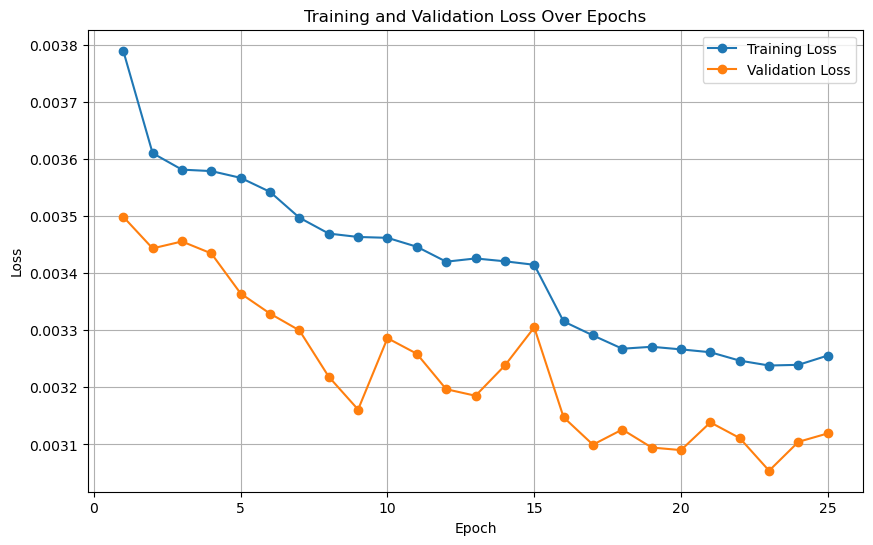

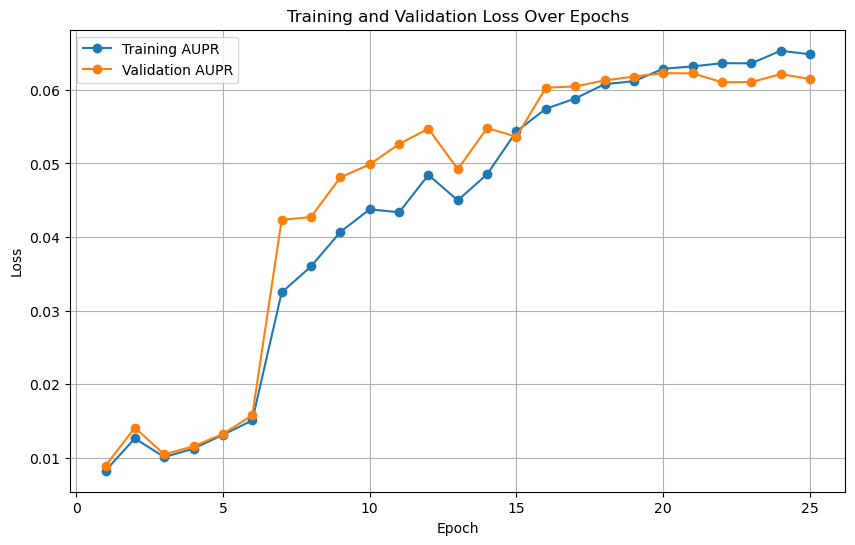

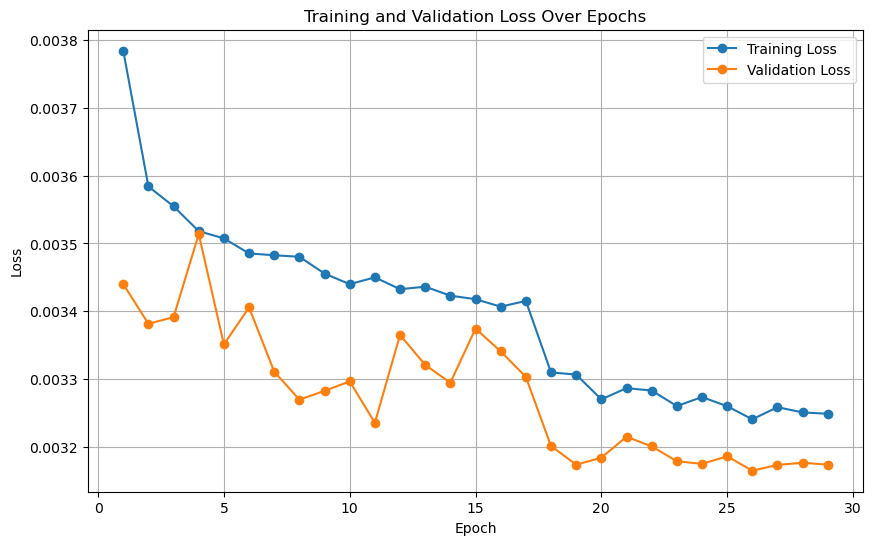

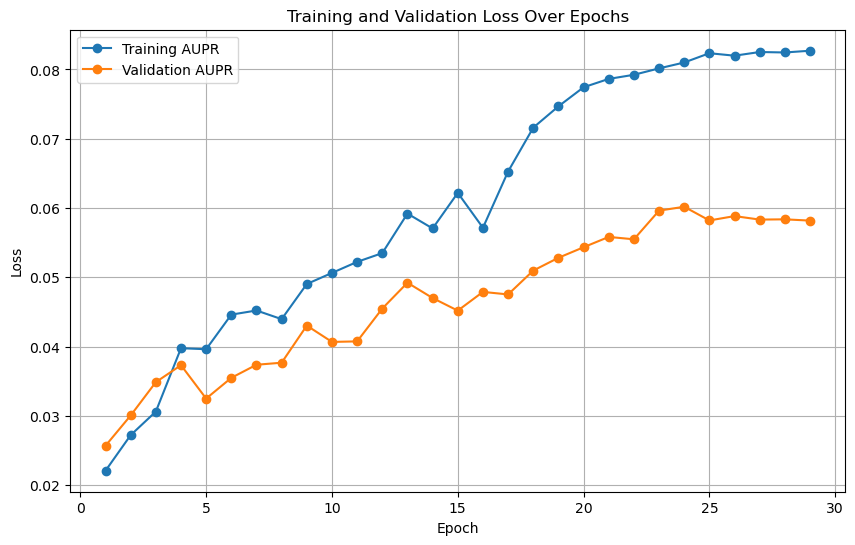

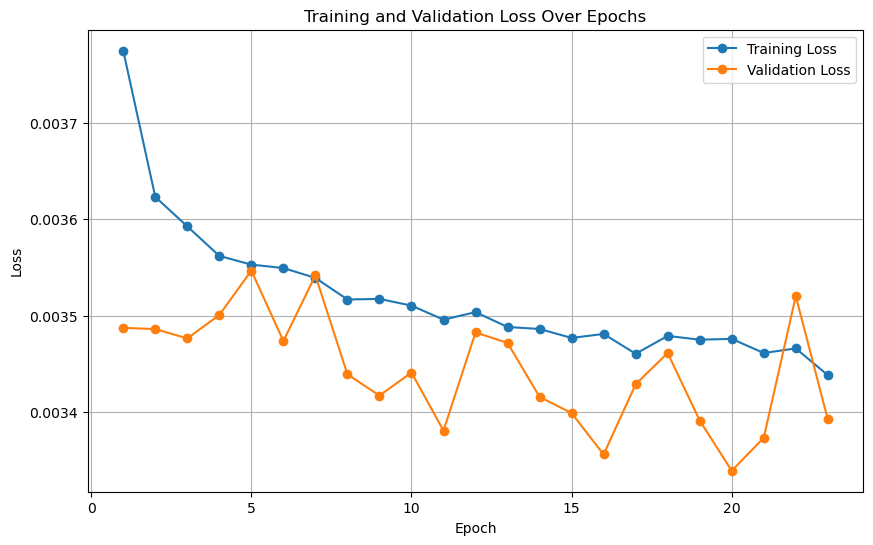

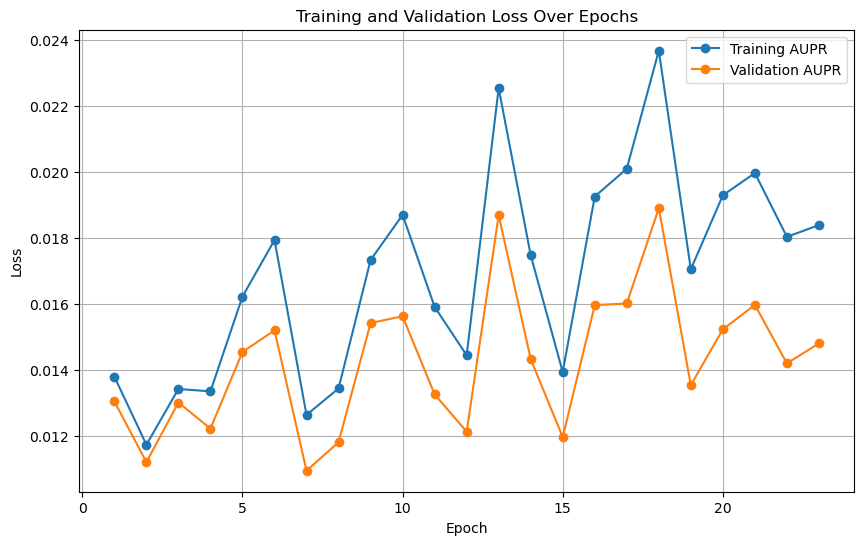

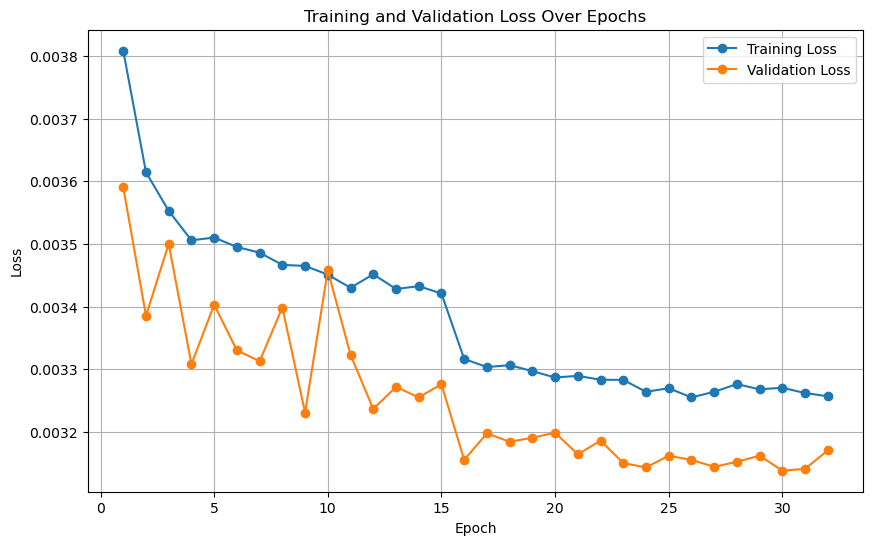

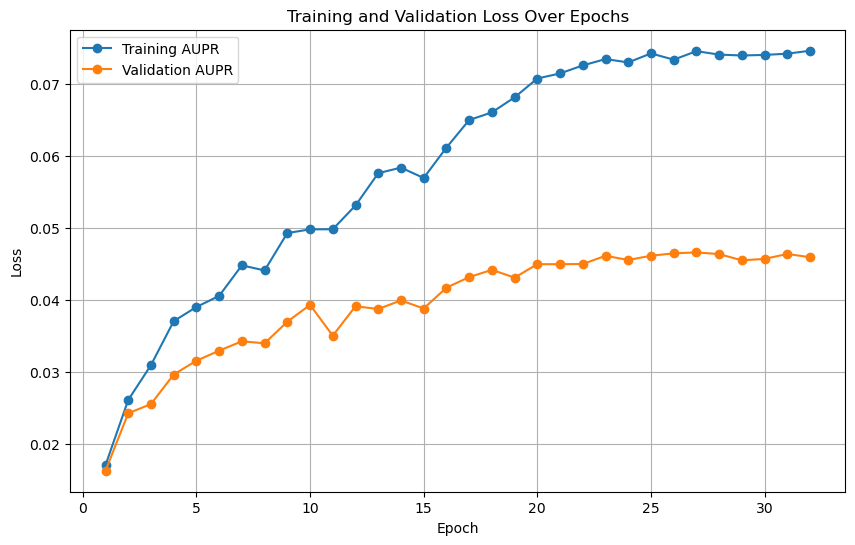

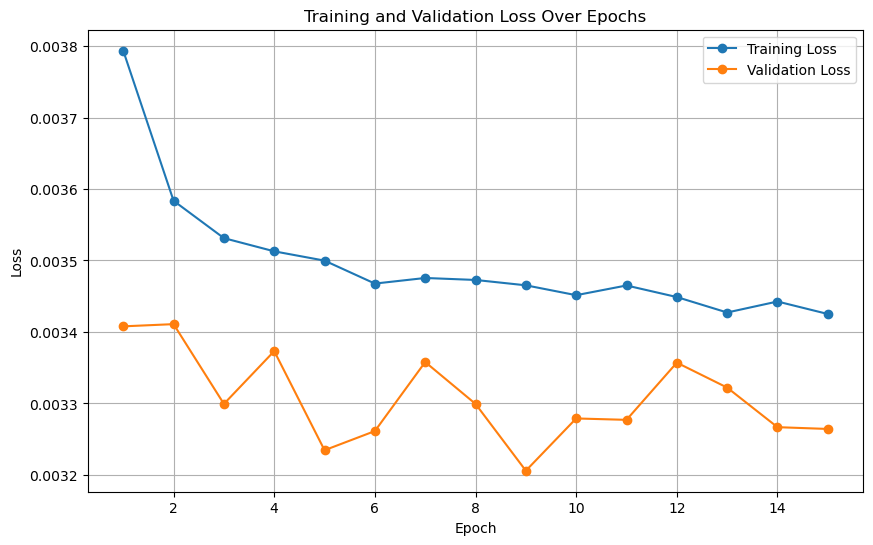

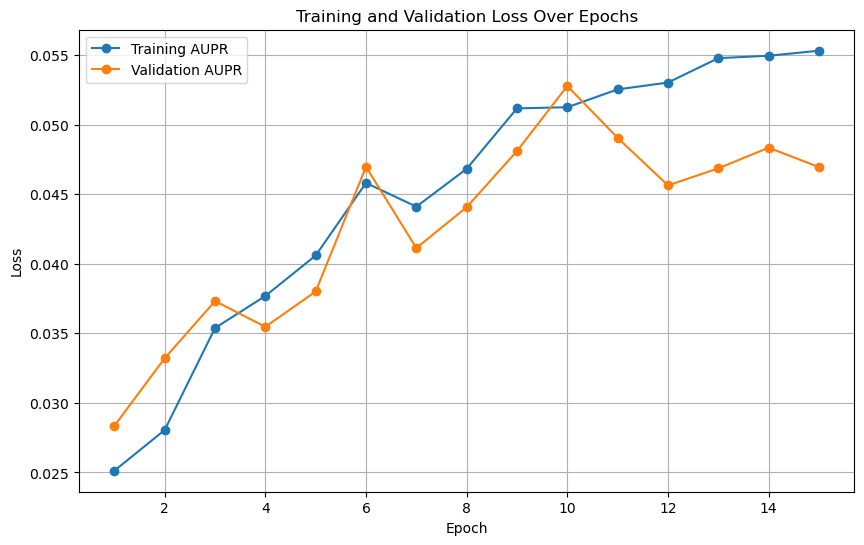

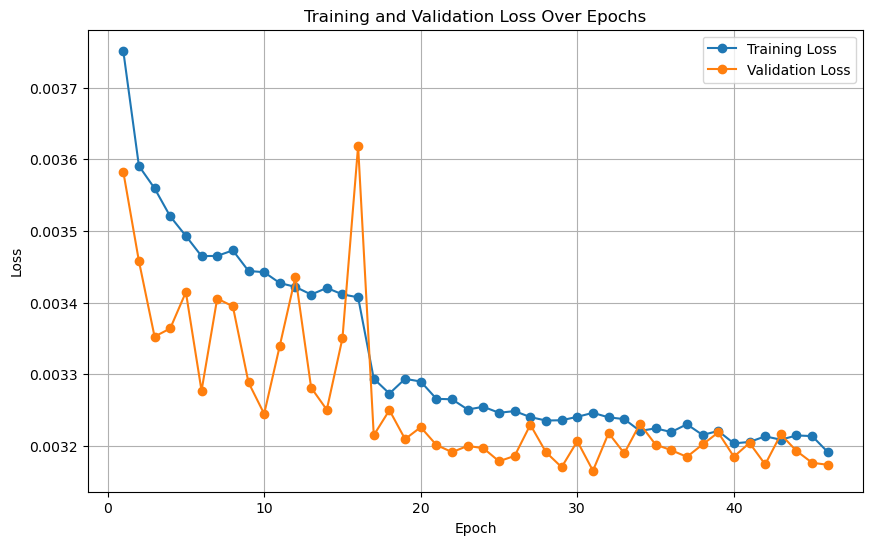

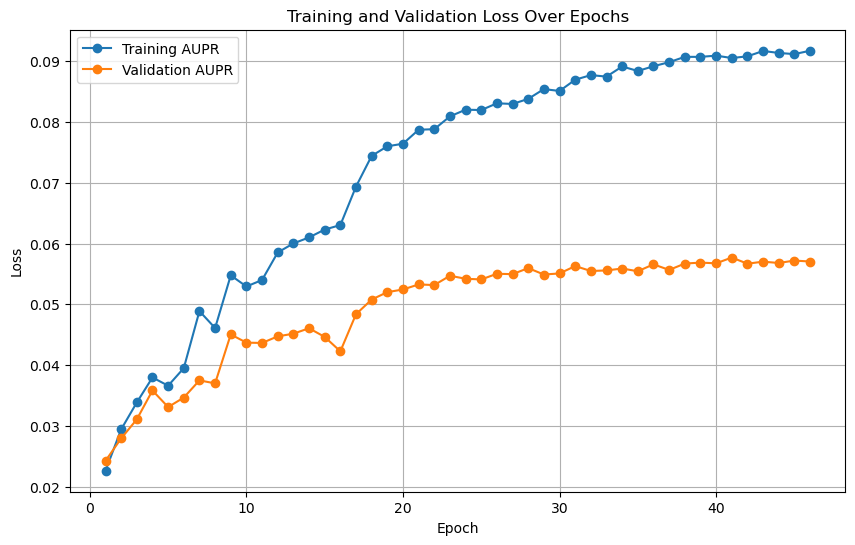

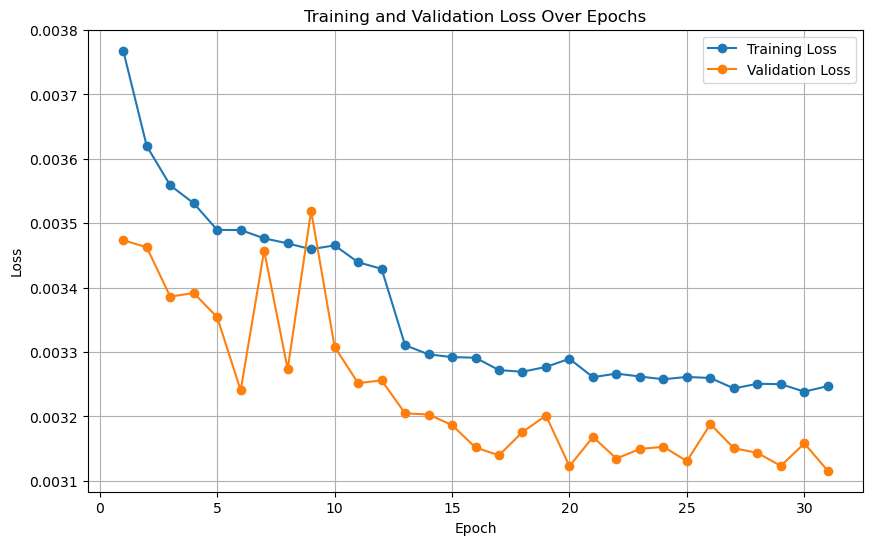

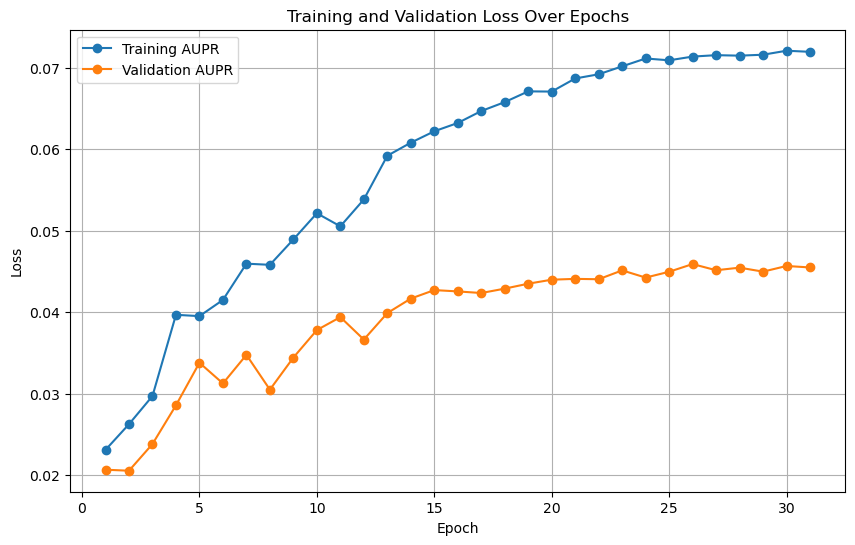

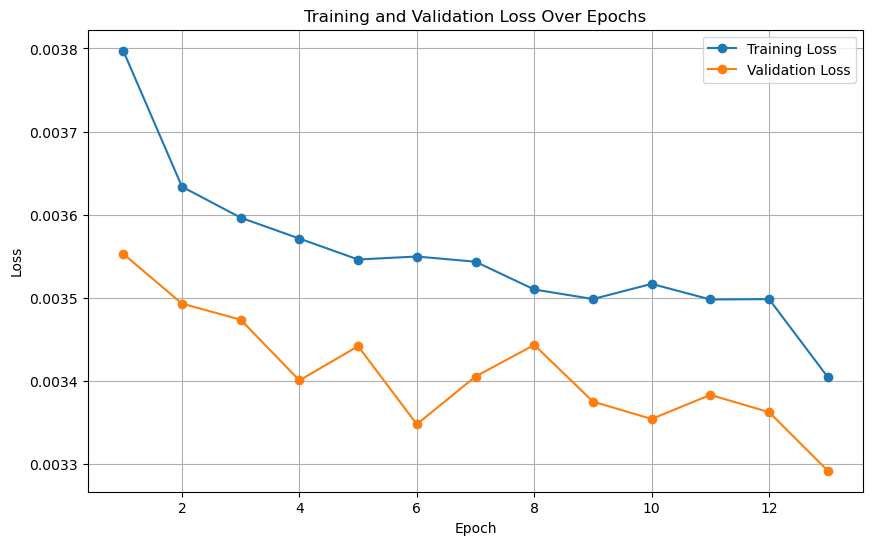

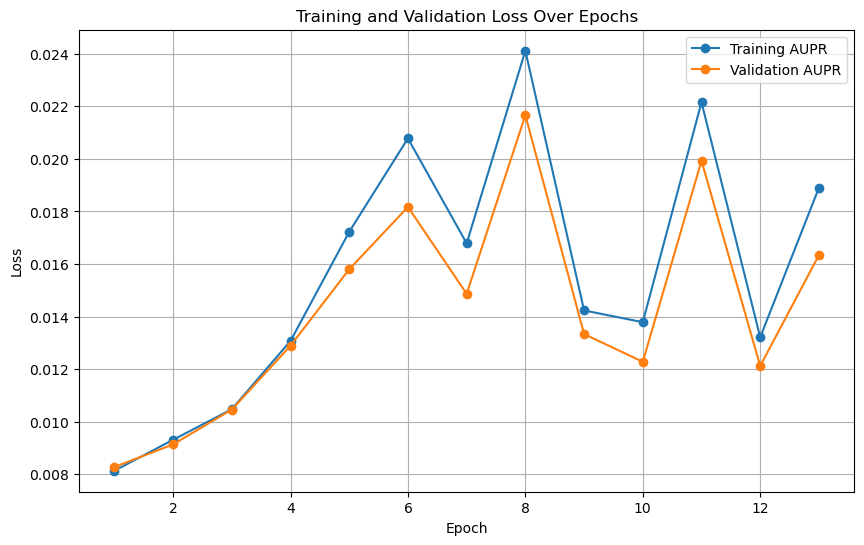

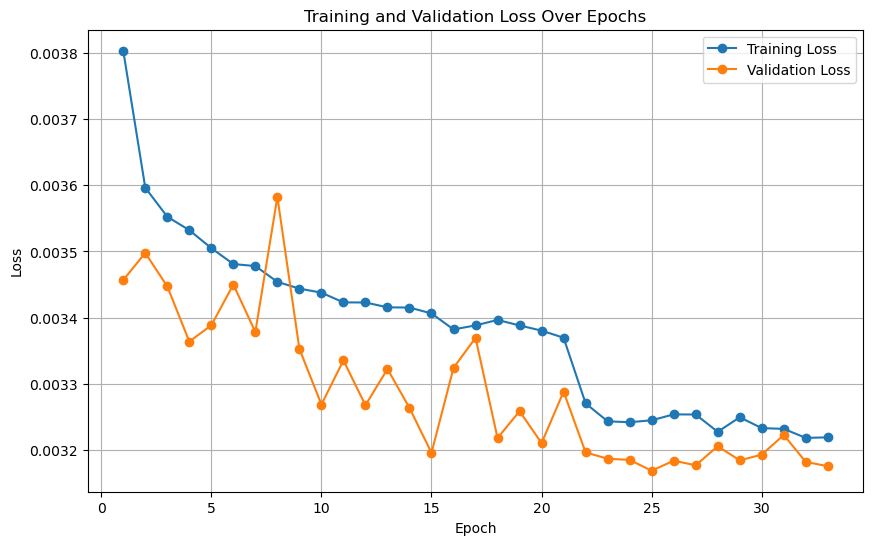

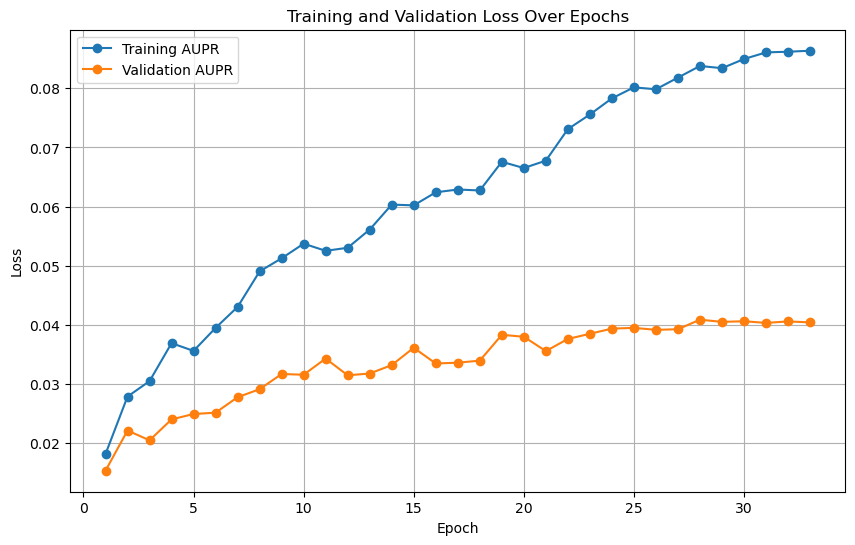

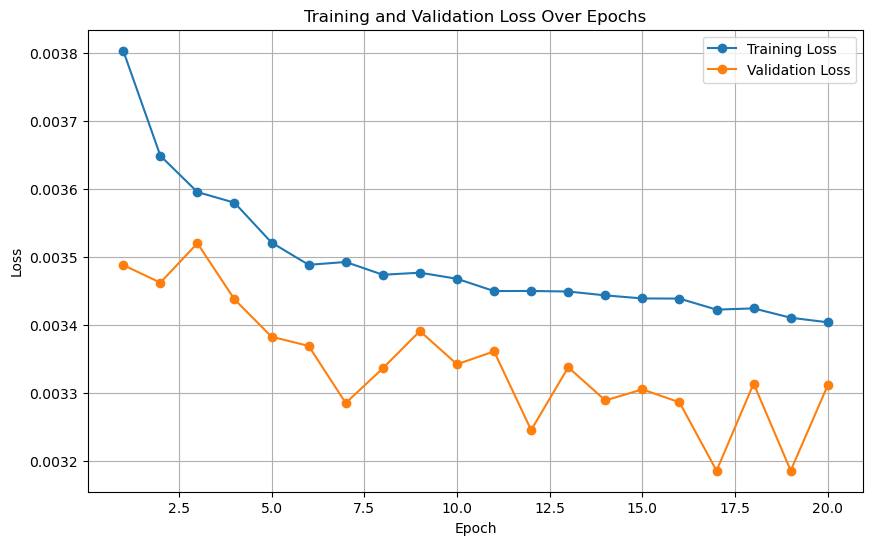

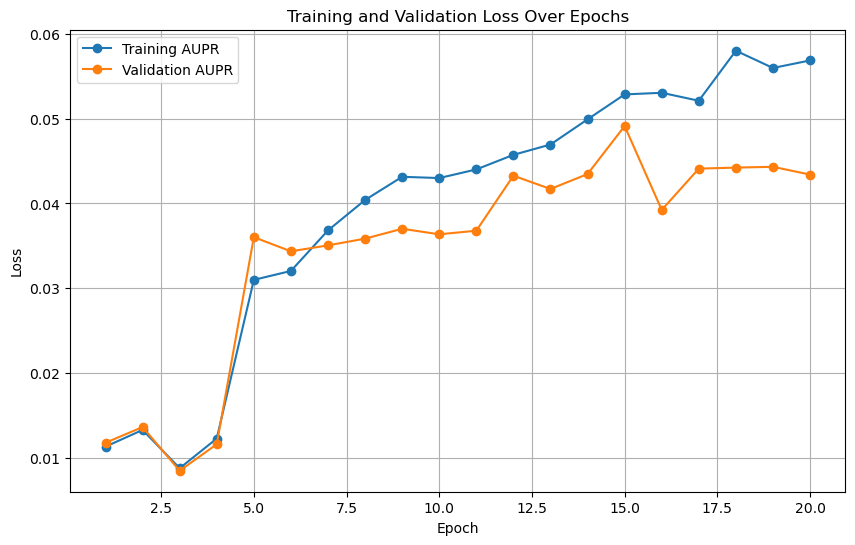

In [17]:
# CV1 on the whole data 
num_e = 50
lr = 1e-2
pt = 5
decay = 0.1
n = 10 # number of cross validations
cv = 1 # random holdout
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/"
prefix = "CV1_811_GIV_NN_LR1e2_50e_p5_d01"
start_i = 1

for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV1_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

In [ ]:
# CV1 on the whole data - more patience
num_e = 50
lr = 1e-2
pt = 10
decay = 0.1
n = 10 # number of cross validations
cv = 1 # random holdout
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/"
prefix = "CV1_811_GIV_NN_LR1e2_50e_p10_d01"
start_i = 1

for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV1_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/' is ready.
Data Split Method: CV1
Train size: 2997488, Validation size: 374686, Test size: 374686
Using cuda device
[2025-07-18 10:19:39] Training started
Epoch 1/50: Train Loss: 0.0038, Val Loss: 0.0035
Epoch 1: Train AUPR=0.0210 AUROC=0.8639 | Val AUPR=0.0297 AUROC=0.8697
Epoch 2/50: Train Loss: 0.0036, Val Loss: 0.0033
Epoch 2: Train AUPR=0.0254 AUROC=0.8779 | Val AUPR=0.0333 AUROC=0.8792
Epoch 3/50: Train Loss: 0.0036, Val Loss: 0.0032
Epoch 3: Train AUPR=0.0308 AUROC=0.8838 | Val AUPR=0.0459 AUROC=0.8857
Epoch 4/50: Train Loss: 0.0035, Val Loss: 0.0032
Epoch 4: Train AUPR=0.0370 AUROC=0.8894 | Val AUPR=0.0493 AUROC=0.8898
Epoch 5/50: Train Loss: 0.0035, Val Loss: 0.0033
Epoch 5: Train AUPR=0.0399 AUROC=0.8906 | Val AUPR=0.0513 AUROC=0.8870
Epoch 6/50: Train Loss: 0.0035, Val Loss: 0.0032
Epoch 6: Train AUPR=0.0399 AUROC=0.8919 | Val AUPR=0.0500 AUROC=0.8861
Epoch 7/50: Train Loss: 0.0035, Val Los

10
Directory '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/' is ready.
Data Split Method: CV1
Train size: 2997488, Validation size: 374686, Test size: 374686
Using cuda device
[2025-07-19 10:36:17] Training started
Epoch 1/50: Train Loss: 0.0038, Val Loss: 0.0034
Epoch 1: Train AUPR=0.0226 AUROC=0.8663 | Val AUPR=0.0256 AUROC=0.8649
Epoch 2/50: Train Loss: 0.0036, Val Loss: 0.0034
Epoch 2: Train AUPR=0.0316 AUROC=0.8772 | Val AUPR=0.0320 AUROC=0.8724
Epoch 3/50: Train Loss: 0.0036, Val Loss: 0.0033
Epoch 3: Train AUPR=0.0335 AUROC=0.8824 | Val AUPR=0.0361 AUROC=0.8771
Epoch 4/50: Train Loss: 0.0035, Val Loss: 0.0034
Epoch 4: Train AUPR=0.0345 AUROC=0.8844 | Val AUPR=0.0307 AUROC=0.8785
Epoch 5/50: Train Loss: 0.0035, Val Loss: 0.0033
Epoch 5: Train AUPR=0.0422 AUROC=0.8904 | Val AUPR=0.0395 AUROC=0.8819
Epoch 6/50: Train Loss: 0.0035, Val Loss: 0.0033
Epoch 6: Train AUPR=0.0434 AUROC=0.8926 | Val AUPR=0.0375 AUROC=0.8839
Epoch 7/50: Train Loss: 0.0035, Val Lo

KeyboardInterrupt: 

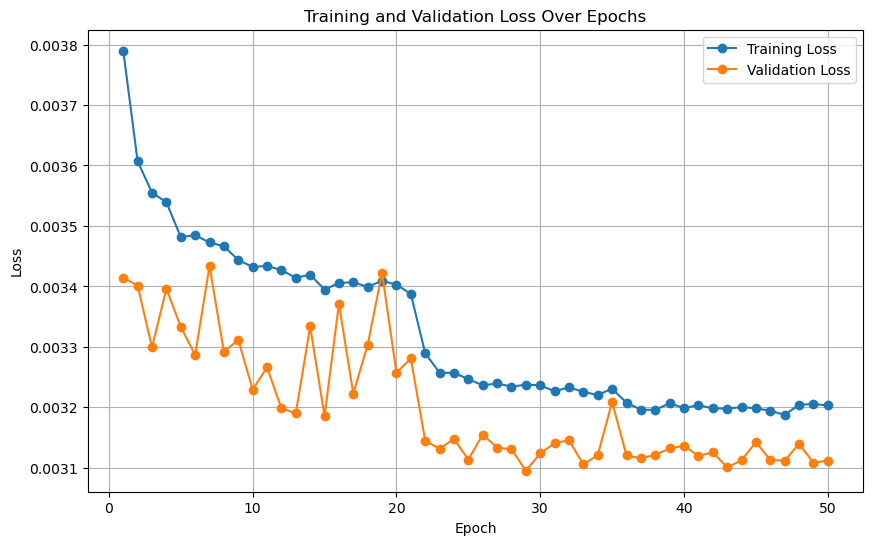

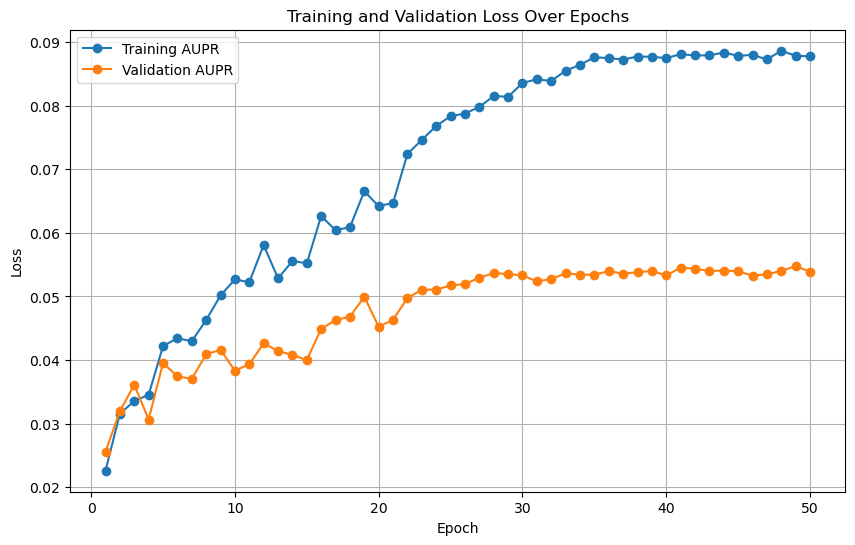

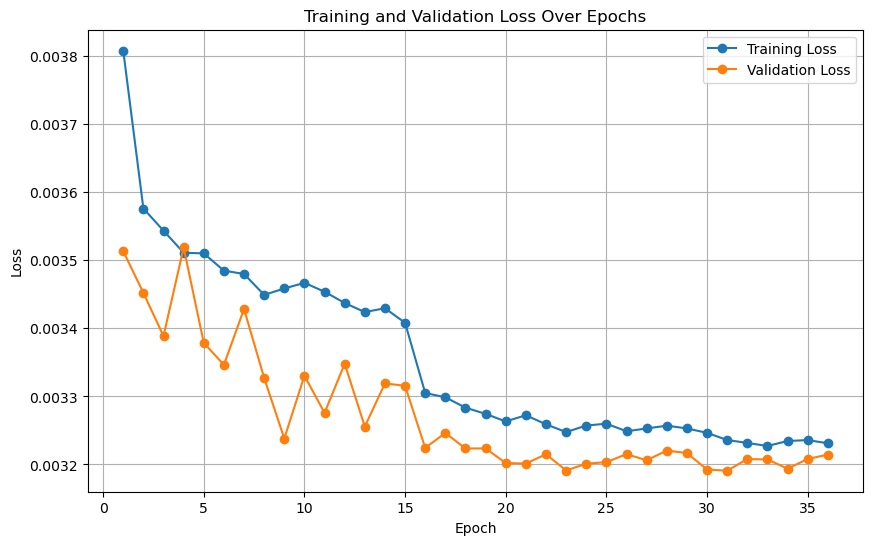

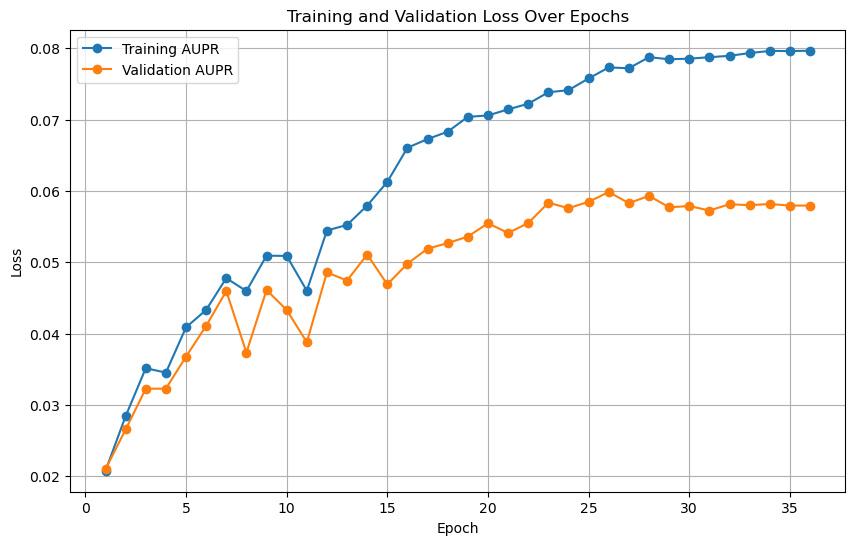

In [15]:
# CV1 on the whole data - more patience
num_e = 50
lr = 1e-2
pt = 10
decay = 0.1
n = 10 # number of cross validations
cv = 1 # random holdout
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/"
prefix = "CV1_811_GIV_NN_LR1e2_50e_p10_d01"
start_i = 10

for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV1_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
# df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
# df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
# print(df_perf.mean(axis=0))
# print(df_perf.std(axis=0))

In [16]:
# Ablation
ko_cols = ['ko_'+str(i) for i in range(128)]

In [17]:
exp_cols = ['exp_'+str(i) for i in range(128)]

In [18]:
df_SL.columns

Index(['Gene', 'Query', 'qGI_score', 'FDR', 'GI_standard', 'GI_stringent',
       'GI_standard_Type1', 'GI_standard_Type2', 'GI_standard_Type3',
       'GI_stringent_Type1',
       ...
       'exp_118', 'exp_119', 'exp_120', 'exp_121', 'exp_122', 'exp_123',
       'exp_124', 'exp_125', 'exp_126', 'exp_127'],
      dtype='object', length=268)

In [19]:
df_SL_ko = df_SL[non_feature_cols + ko_cols]

In [28]:
df_SL_exp = df_SL[non_feature_cols + exp_cols]

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_CV1_ablation/' is ready.
Data Split Method: CV1
Train size: 2997488, Validation size: 374686, Test size: 374686
Using cuda device
[2025-07-10 11:11:20] Training started
Epoch 1/50: Train Loss: 0.0039, Val Loss: 0.0035
Epoch 1: Train AUPR=0.0146 AUROC=0.8189 | Val AUPR=0.0208 AUROC=0.8166
Epoch 2/50: Train Loss: 0.0038, Val Loss: 0.0035
Epoch 2: Train AUPR=0.0170 AUROC=0.8389 | Val AUPR=0.0202 AUROC=0.8393
Epoch 3/50: Train Loss: 0.0037, Val Loss: 0.0034
Epoch 3: Train AUPR=0.0206 AUROC=0.8471 | Val AUPR=0.0230 AUROC=0.8483
Epoch 4/50: Train Loss: 0.0037, Val Loss: 0.0036
Epoch 4: Train AUPR=0.0248 AUROC=0.8495 | Val AUPR=0.0258 AUROC=0.8476
Epoch 5/50: Train Loss: 0.0037, Val Loss: 0.0035
Epoch 5: Train AUPR=0.0257 AUROC=0.8580 | Val AUPR=0.0257 AUROC=0.8495
Epoch 6/50: Train Loss: 0.0036, Val Loss: 0.0034
Epoch 6: Train AUPR=0.0306 AUROC=0.8582 | Val AUPR=0.0294 AUROC=0.8553
Epoch 7/50: Train Loss: 0.0036,

KeyboardInterrupt: 

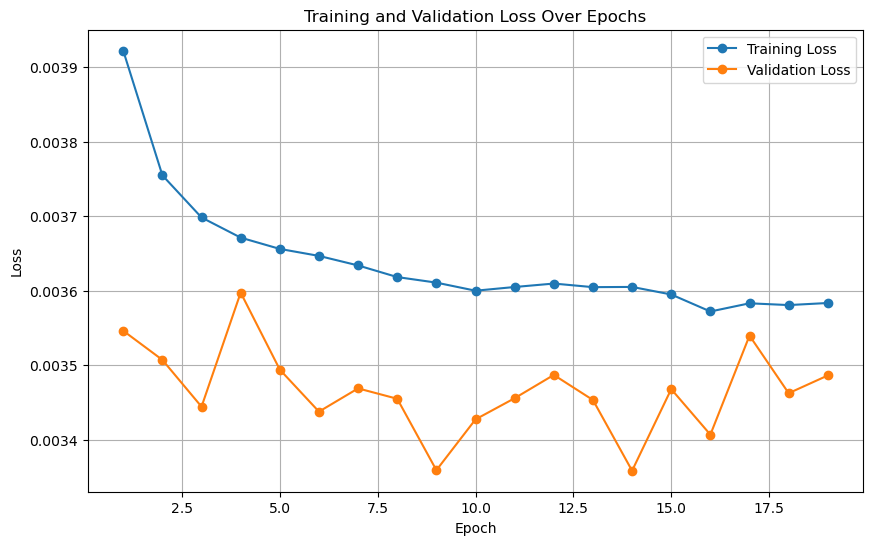

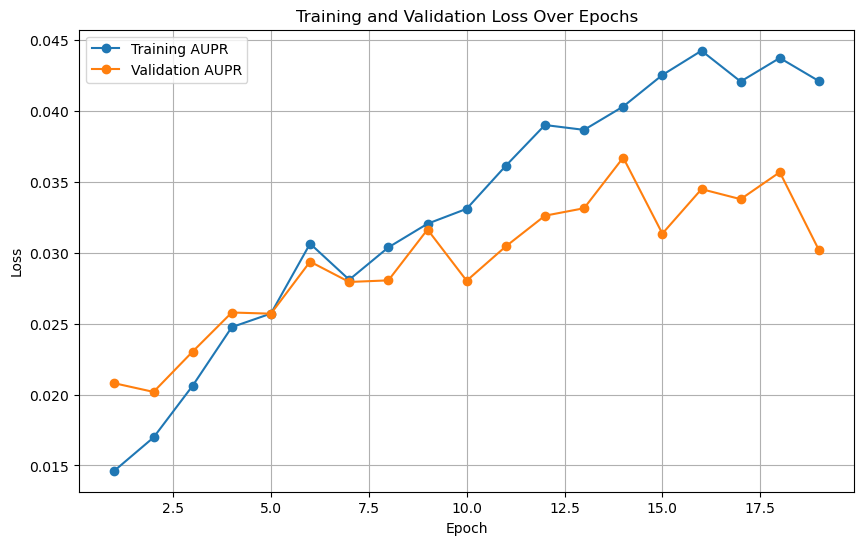

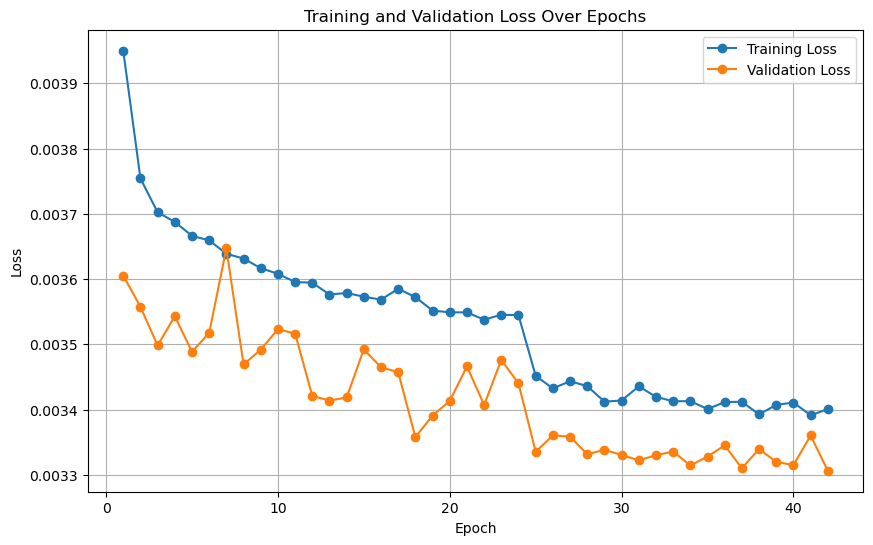

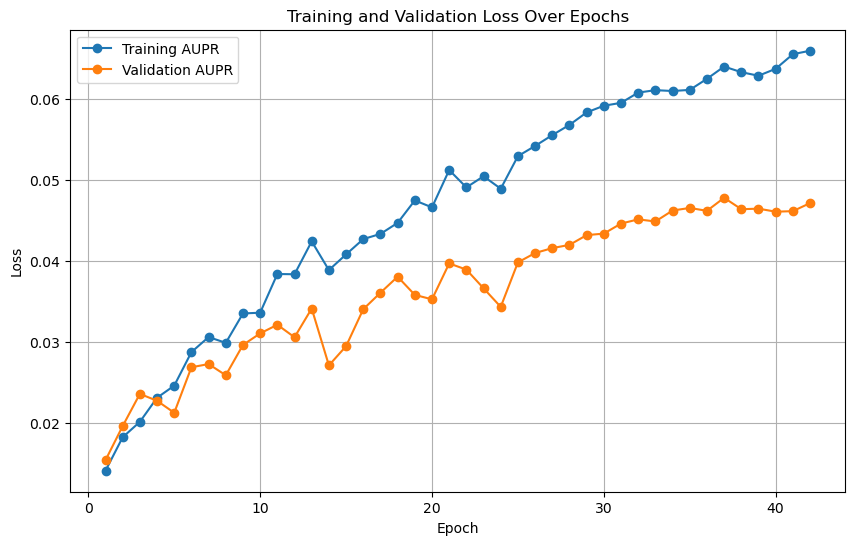

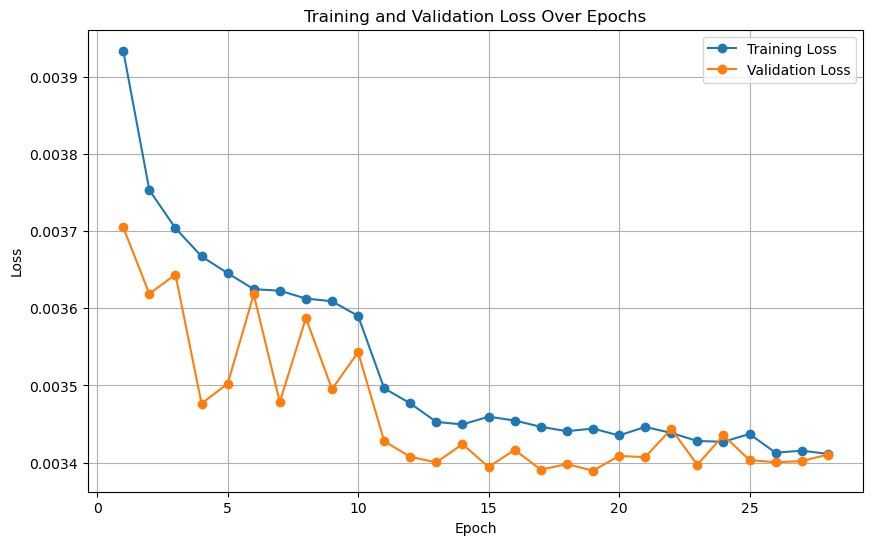

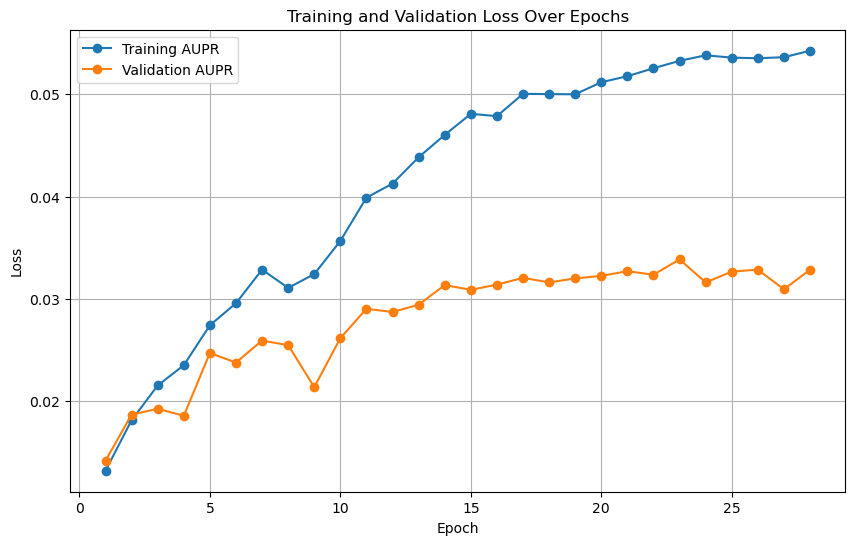

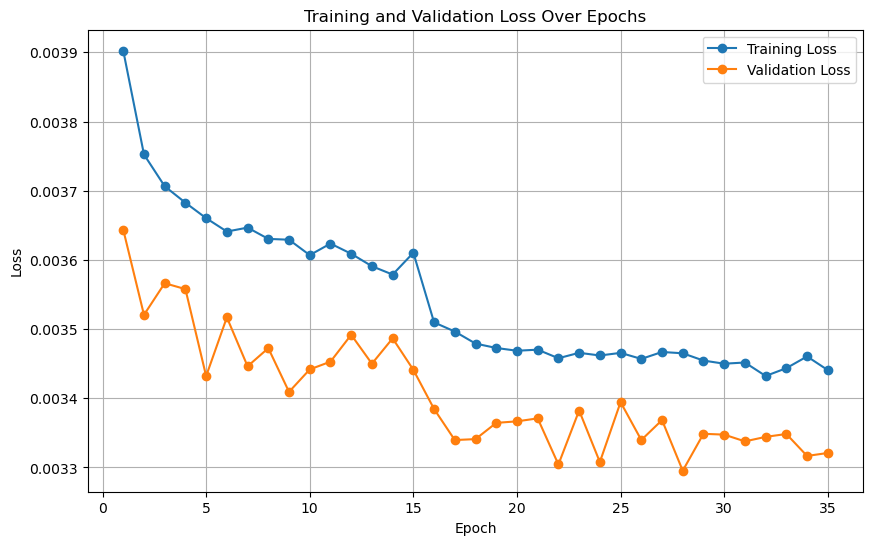

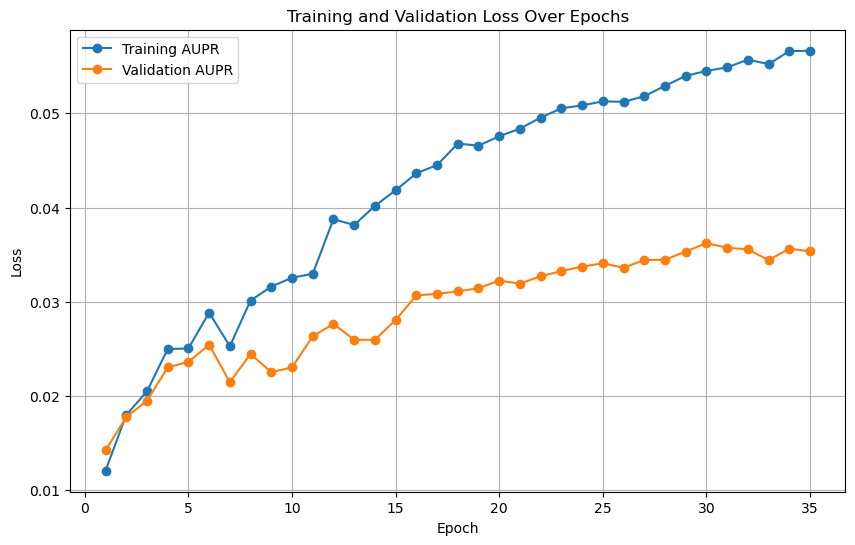

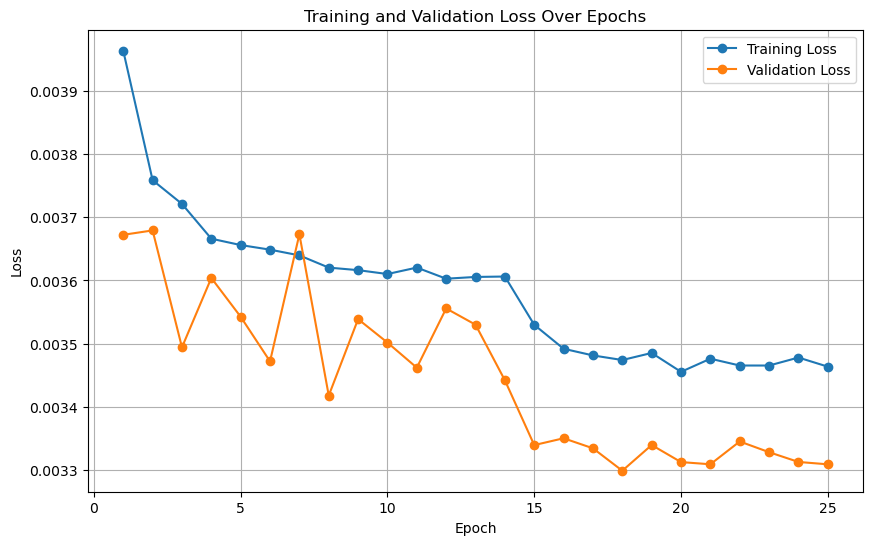

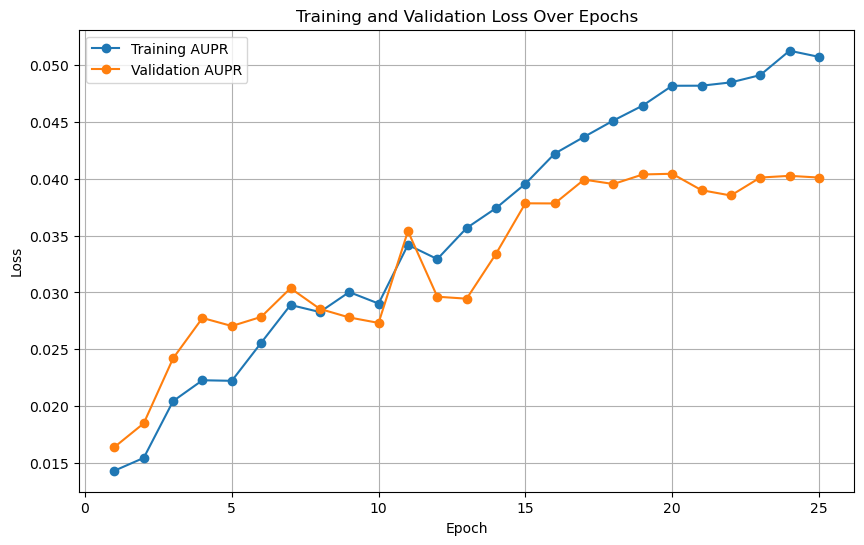

In [29]:
# CV1 on the whole data 
num_e = 50
lr = 1e-2
pt = 5
decay = 0.1
n = 10 # number of cross validations
cv = 1 # random holdout
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_CV1_ablation/"
prefix = "CV1_811_GIV_NN_LR1e2_50e_p5_d01"
start_i = 1

for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL_ko,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV1_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

In [ ]:
# CV1 on the whole data 
num_e = 50
lr = 1e-2
pt = 5
decay = 0.1
n = 10 # number of cross validations
cv = 1 # random holdout
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_CV1_ablation/"
prefix = "CV1_811_GIV_NN_LR1e2_50e_p5_d01"
start_i = 6

for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL_ko,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV1_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

6
Directory '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_CV1_ablation/' is ready.
Data Split Method: CV1
Train size: 2997488, Validation size: 374686, Test size: 374686
Using cuda device
[2025-07-10 20:02:10] Training started
Epoch 1/50: Train Loss: 0.0040, Val Loss: 0.0037
Epoch 1: Train AUPR=0.0132 AUROC=0.8107 | Val AUPR=0.0130 AUROC=0.8155
Epoch 2/50: Train Loss: 0.0038, Val Loss: 0.0036
Epoch 2: Train AUPR=0.0145 AUROC=0.8347 | Val AUPR=0.0155 AUROC=0.8359
Epoch 3/50: Train Loss: 0.0037, Val Loss: 0.0035
Epoch 3: Train AUPR=0.0196 AUROC=0.8457 | Val AUPR=0.0197 AUROC=0.8424
Epoch 4/50: Train Loss: 0.0037, Val Loss: 0.0036
Epoch 4: Train AUPR=0.0216 AUROC=0.8448 | Val AUPR=0.0196 AUROC=0.8379
Epoch 5/50: Train Loss: 0.0037, Val Loss: 0.0035
Epoch 5: Train AUPR=0.0242 AUROC=0.8517 | Val AUPR=0.0213 AUROC=0.8472
Epoch 6/50: Train Loss: 0.0037, Val Loss: 0.0035
Epoch 6: Train AUPR=0.0237 AUROC=0.8536 | Val AUPR=0.0226 AUROC=0.8451
Epoch 7/50: Train Loss: 0.0036,

In [ ]:
# Ablation CV1 for each feature set

In [ ]:
# Ablation CV2 for each feature set

In [13]:
# CV2 on the whole data 
num_e = 50
lr = 1e-2
pt = 10
decay = 0.1
n = 10 # number of cross validations
cv = 2 # hold out query only
K = 100 # Top K for PR

perf_list = []
output_dir = "/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f/"
prefix = "CV2_811_GIV_NN_LR1e2_50e_p10_d01"
start_i = 1

1
Directory '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_5L_f/' is ready.
Data Split Method: CV2
220 of unique queries in total
22 queries held out for validation set
22 queries held out for test set
(2997506, 256)
(374711, 256)
(374643, 256)
Final test ratio of pairs: 0.09998852372386478
Final test:train ratio 0.11109918333976346
Using cuda device
[2025-07-04 11:03:09] Training started
Epoch 1/50: Train Loss: 0.0040, Val Loss: 0.0053
Epoch 1: Train AUPR=0.0110 AUROC=0.8404 | Val AUPR=0.0219 AUROC=0.8498
Epoch 2/50: Train Loss: 0.0038, Val Loss: 0.0050
Epoch 2: Train AUPR=0.0193 AUROC=0.8548 | Val AUPR=0.0288 AUROC=0.8564
Epoch 3/50: Train Loss: 0.0037, Val Loss: 0.0052
Epoch 3: Train AUPR=0.0190 AUROC=0.8582 | Val AUPR=0.0194 AUROC=0.8526
Epoch 4/50: Train Loss: 0.0037, Val Loss: 0.0049
Epoch 4: Train AUPR=0.0200 AUROC=0.8639 | Val AUPR=0.0174 AUROC=0.8526
Epoch 5/50: Train Loss: 0.0037, Val Loss: 0.0051
Epoch 5: Train AUPR=0.0211 AUROC=0.8670 | Val AUPR=0.0284 AU

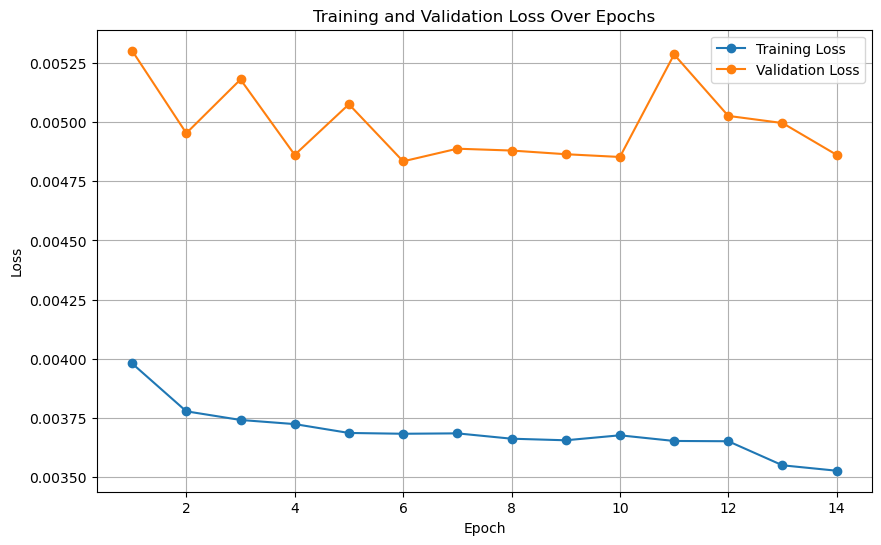

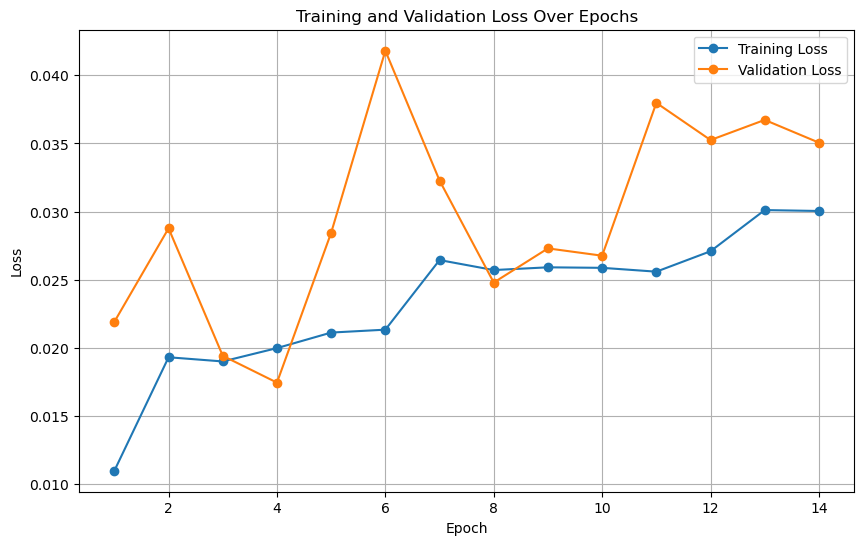

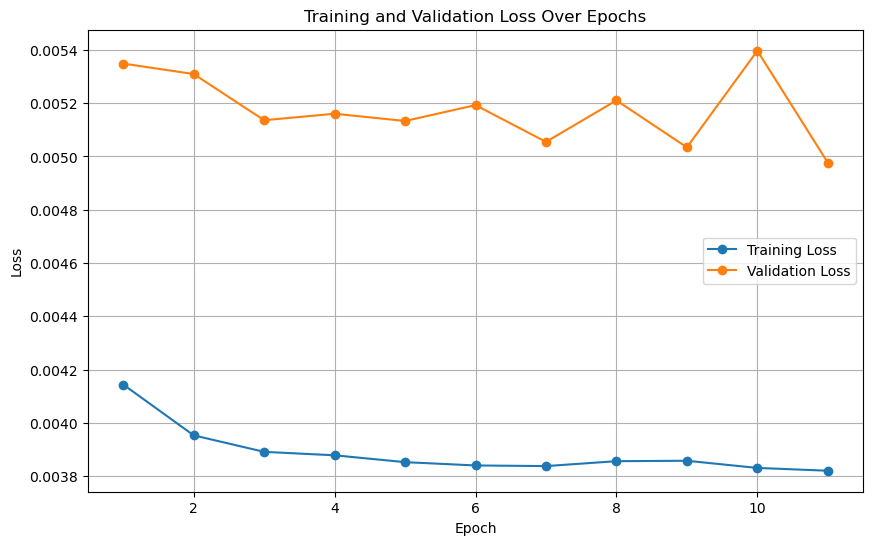

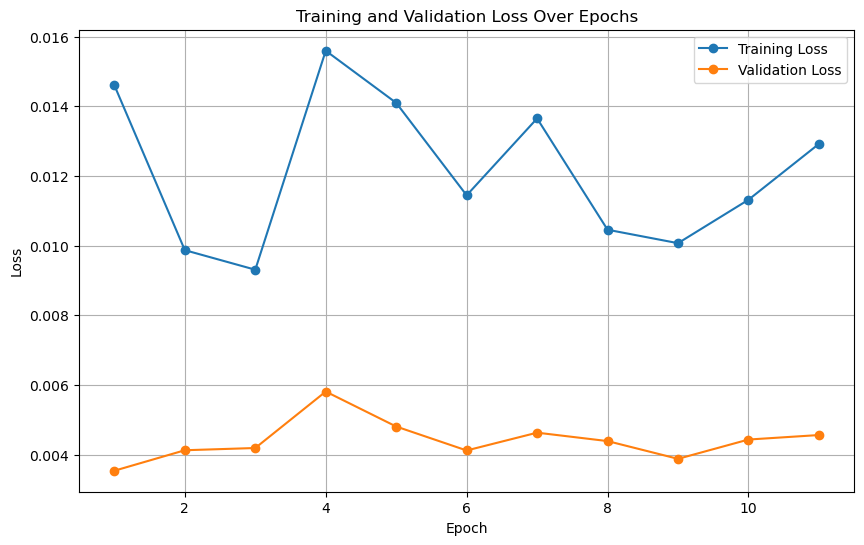

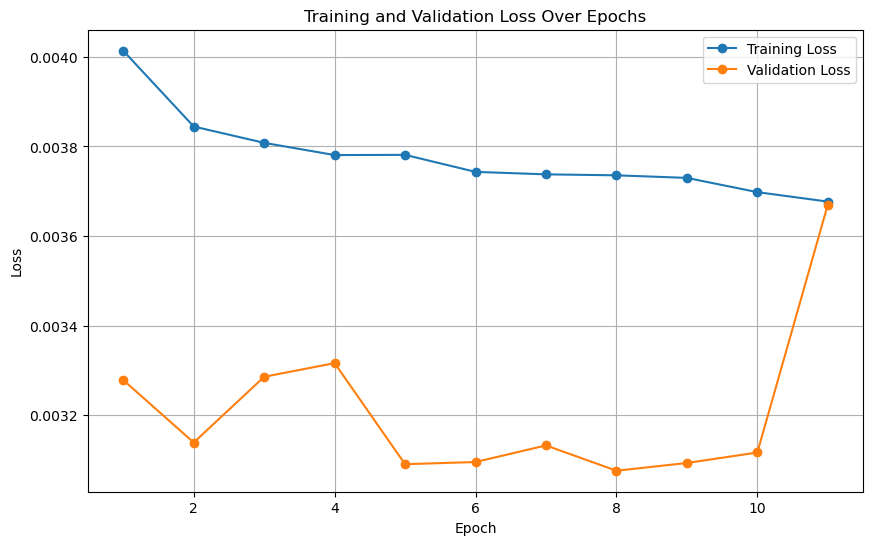

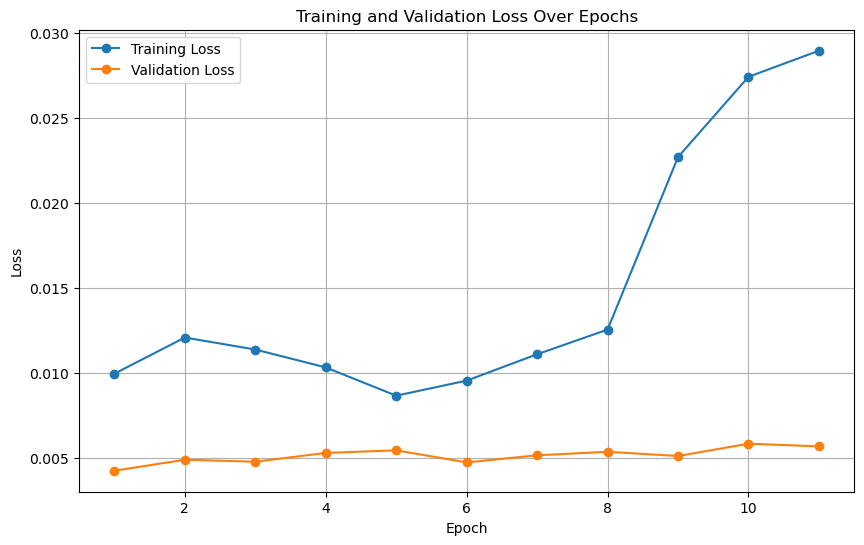

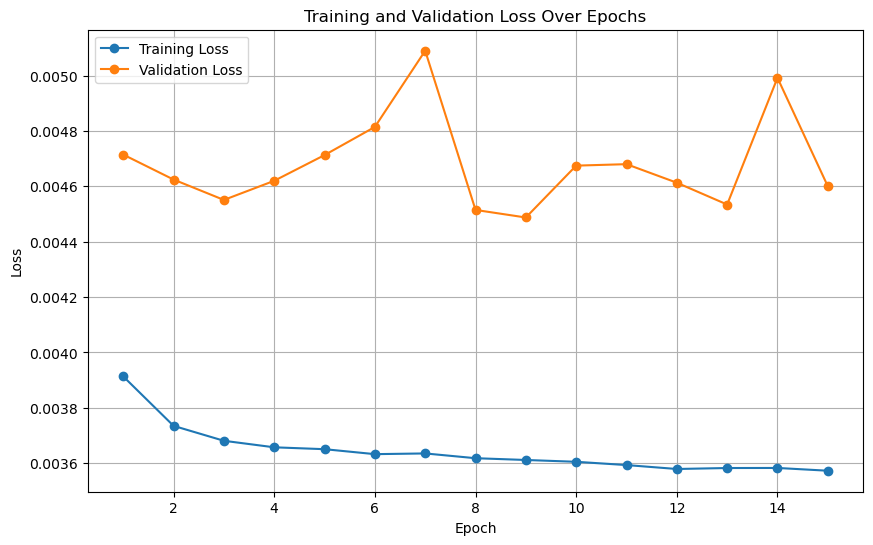

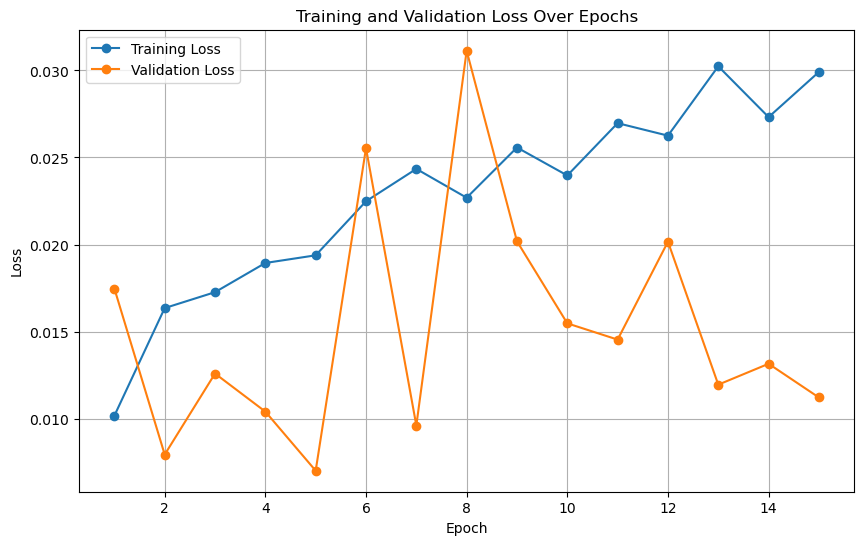

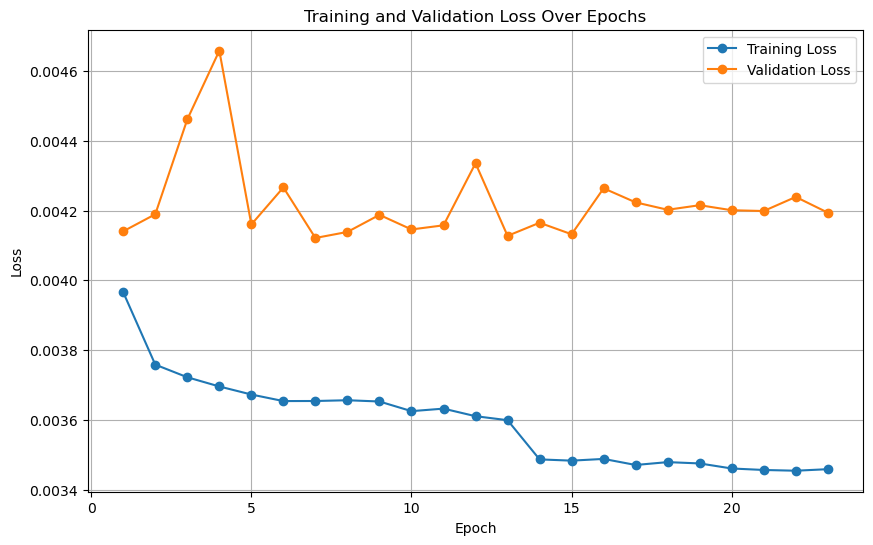

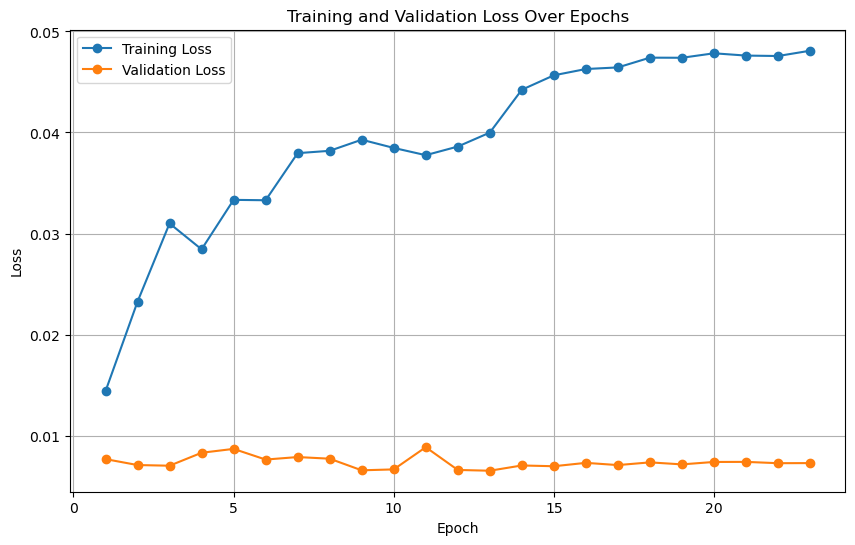

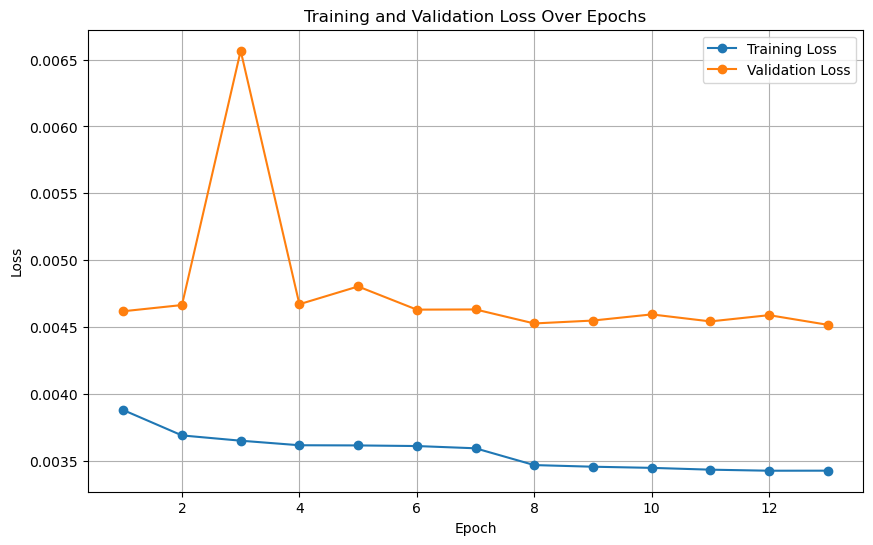

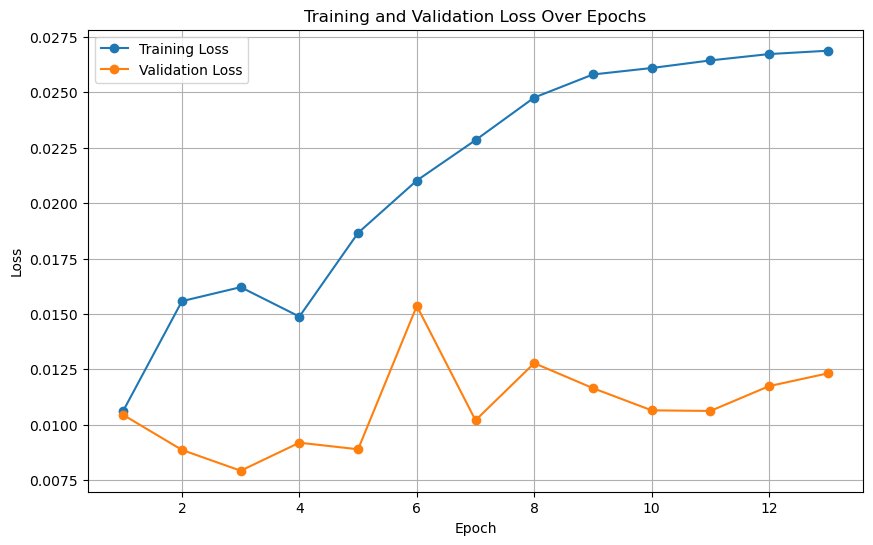

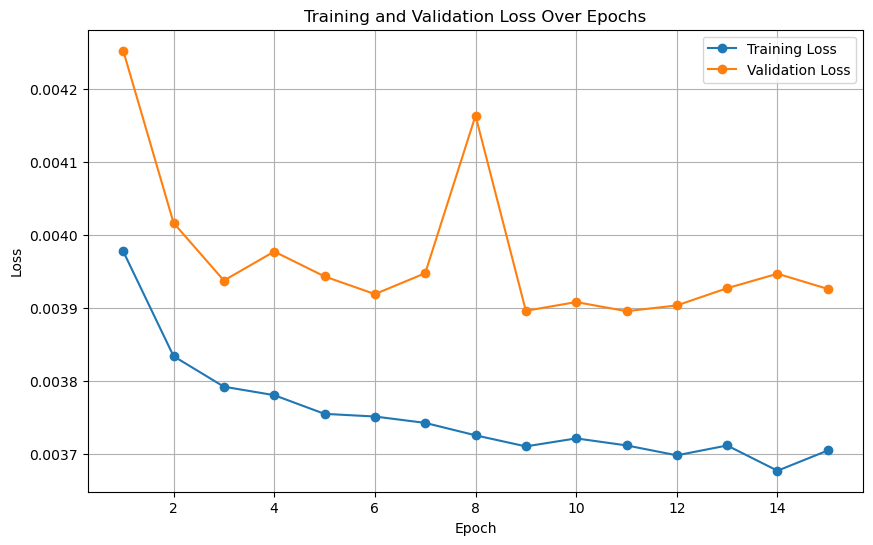

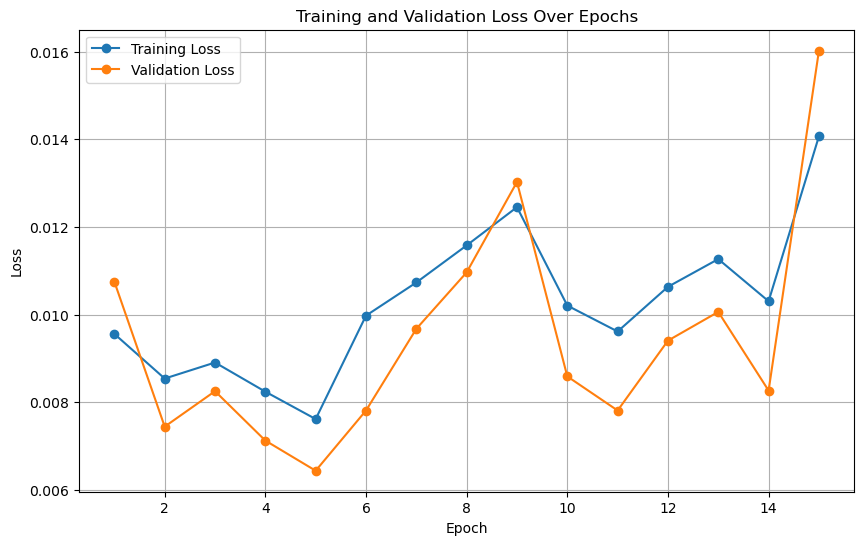

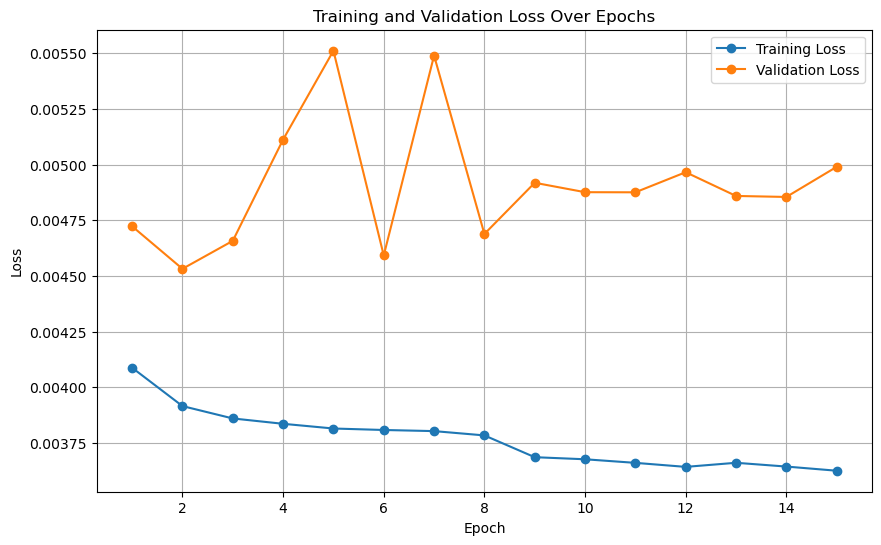

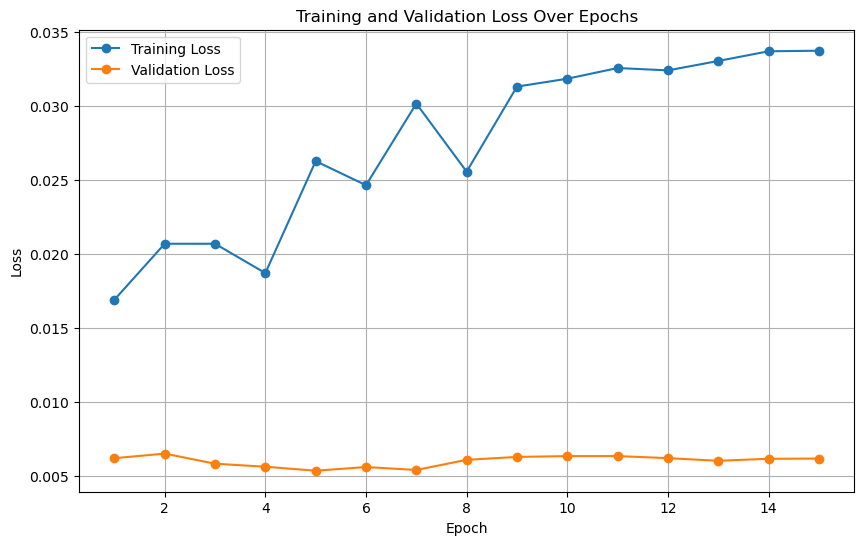

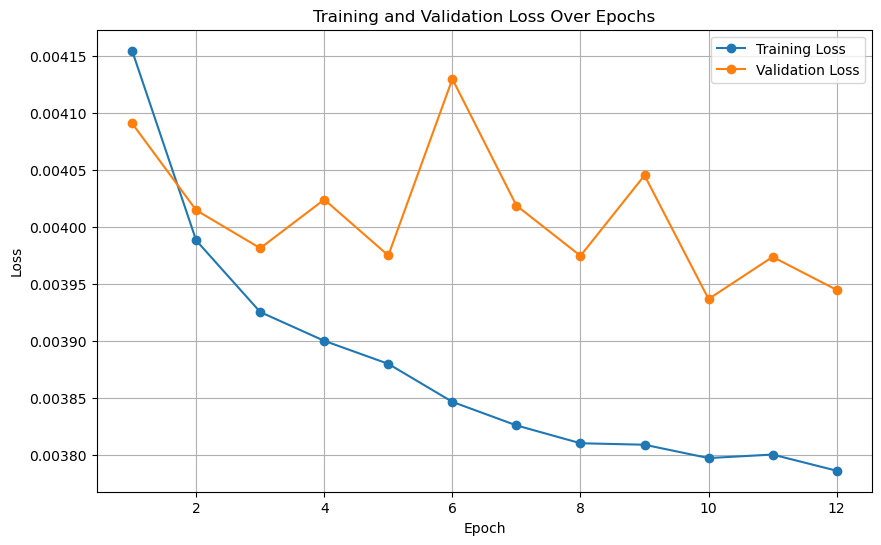

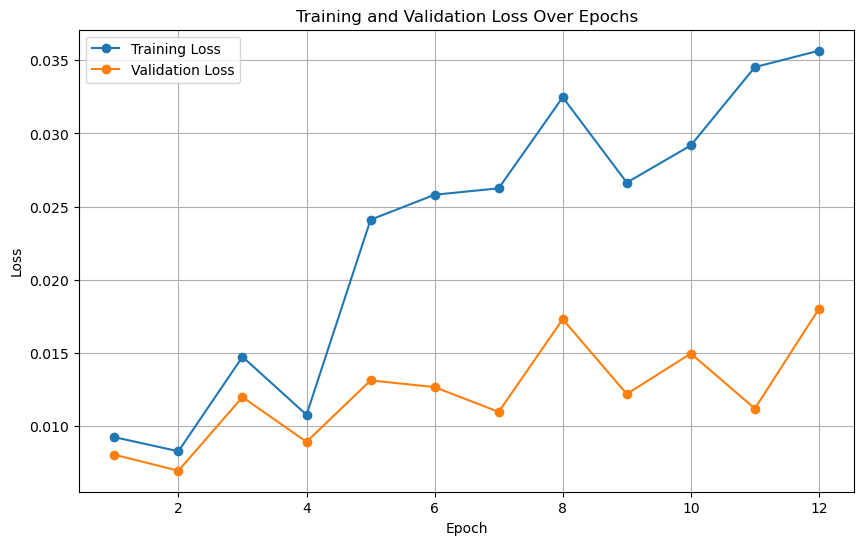

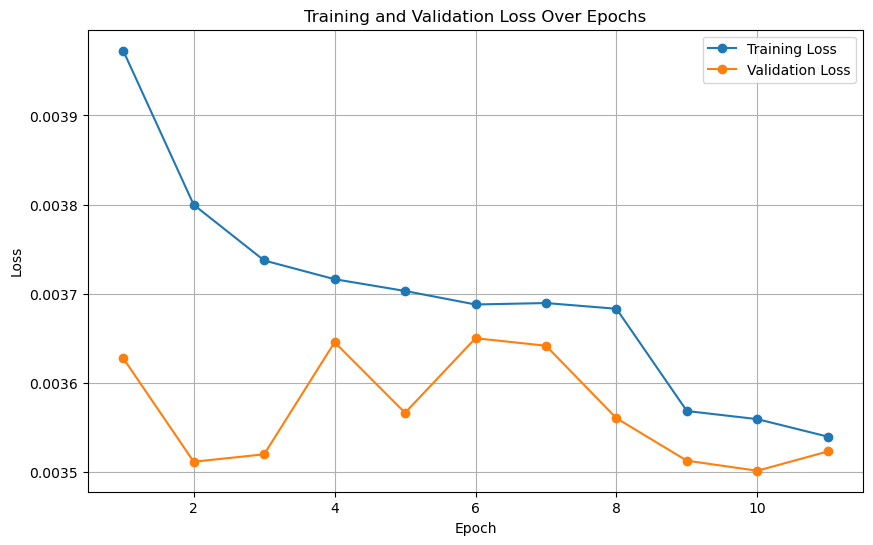

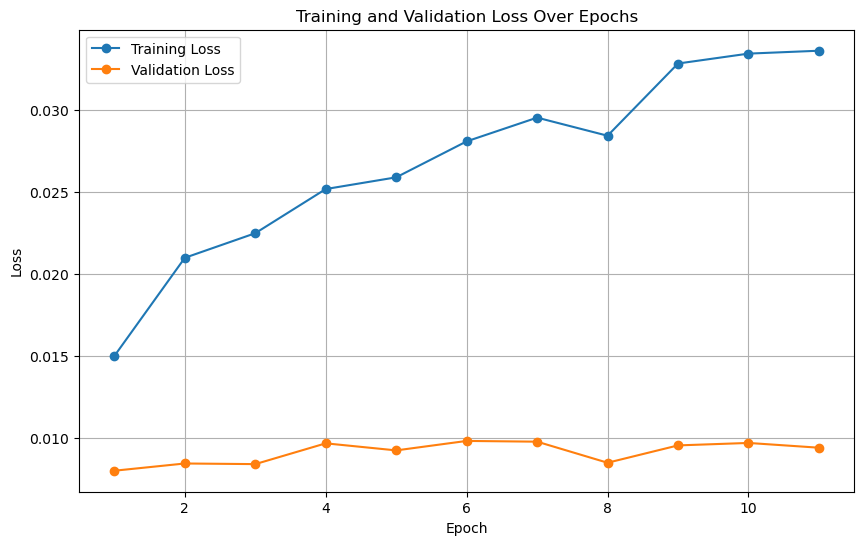

In [15]:
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    model, df_test, perf_ = optim_NN_pipeline(df_score=df_SL,
                     label_col='GI_stringent_Type2', non_feature_cols=non_feature_cols,
                     test_ratio=0.1, val_ratio=0.1, rand_seed=i+1842,
                     output_dir=output_dir,
                     plt_name=prefix+'_ROC_PR_curves_{}.pdf'.format(r),
                     table_name=prefix+'_{}.tsv'.format(r),
                     learning_rate=lr, num_epochs=num_e, patience=pt, decay_factor=decay,
                     hidden_size1=128, hidden_size2=64, hidden_size3=32,
                     bool_save_model=True, model_name=prefix+'_{}.pth'.format(r),
                     scaler_direc='CV2_811_seed{}.joblib'.format(r), bool_plot_loss=True, cv=cv,
                     query_col='Query', lib_col='Gene', topk=K)
    perf_list.append(perf_)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_dir+prefix+'_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))